<a href="https://colab.research.google.com/github/Jittiphat-s/GoogleColab_ML_file_CTGAN/blob/main/(CTGAN)8_5_69.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#STEP 1 : IMPORT & LOAD DATA

##Step1.1ติดตั้งไลบารี่

In [6]:
!pip install fuzzywuzzy
!pip install python-Levenshtein

!pip install openpyxl
!pip install rapidfuzz


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 122.0 MB/s eta 0:00:00


##Step1.2 โหลดไลบรารี + ตั้งค่า BASE / encoding

โหลดไลบรารีที่ใช้ (re/numpy/pandas/openpyxl), ตั้งค่า BASE และ encoding (ENC_IPD_DATA, ENC_CULTURE) และเตรียมฟังก์ชัน normalize_columns() เพื่อทำให้ชื่อคอลัมน์เป็นตัวพิมพ์เล็กและตัดช่องว่าง

In [7]:
import re                                  # เรียกความสามารถจัดการตัวหนังสือแบบมีแบบแผน เช่น เอาตัวอักษรในวงเล็บออก
import numpy as np                         # เรียกความสามารถคำนวณจำนวนและค่าที่ว่าง
import pandas as pd                        # เรียกความสามารถจัดการตารางข้อมูล
from openpyxl import Workbook              # เรียกความสามารถสร้างไฟล์ตารางแบบเปิดในโปรแกรมตารางได้
from openpyxl.styles import PatternFill, Alignment  # เรียกความสามารถเติมสีพื้นหลังและจัดการวางข้อความในตาราง
from openpyxl.utils.dataframe import dataframe_to_rows  # เรียกความสามารถแปลงตารางให้กลายเป็นแถวสำหรับเขียนลงไฟล์

BASE = "/content/drive/MyDrive/Colab Notebooks/FileDATA"  # ระบุโฟลเดอร์ที่วางไฟล์ข้อมูลของเรา
ENC_IPD_DATA = "utf-8-sig"                 # ระบุรูปแบบตัวหนังสือสำหรับไฟล์ข้อมูลผู้ป่วย (อ่านภาษาไทยได้ดี)
ENC_CULTURE  = "iso8859_11"                # ระบุรูปแบบตัวหนังสือสำหรับไฟล์ผลเพาะเชื้อที่เป็นของเก่า (อ่านไทยเก่าได้)

def normalize_columns(df):
    df.columns = df.columns.str.lower().str.strip()
    return df

##Step1.3 อ่านไฟล์ IPD_Data, IPD_Cul, OPD_Cul

* อ่าน IPD_Data.txt ด้วยตัวคั่นแท็บ (sep="\t") และ encoding=ENC_IPD_DATA จากนั้น normalize ชื่อคอลัมน์ และคัดเฉพาะคอลัมน์สำคัญไว้สำหรับ enrich (เช่น เพศ อายุ vn/an/วันที่)

* อ่าน IPD_Cul02.txt (หรือชื่อไฟล์ที่ใช้งานจริง) ด้วย encoding=ENC_CULTURE, ปรับชื่อคอลัมน์ และคัดคอลัมน์ที่จำเป็นในการวิเคราะห์ เช่น (hn/an/vn, org, anti/anti_name, anti_result, anti_mic, date_r, time_r, lst/rep เป็นต้น)

* อ่านไฟล์ OPD culture และปรับชื่อคอลัมน์ให้สอดคล้องกับ IPD (รวมถึง vn) เพื่อเตรียมรวมเป็นฐานเดียวกัน

In [8]:
def _read_ipd_data(path, enc):
    try:
        df = pd.read_csv(path, sep=",", encoding=enc, low_memory=False)
        if df.shape[1] == 1:
            df = pd.read_csv(path, sep="\t", encoding=enc, low_memory=False)
    except Exception:
        df = pd.read_csv(path, sep="\t", encoding=enc, low_memory=False)
    df = normalize_columns(df)

    # Cleaning เบื้องต้น
    if 'sex' in df.columns:
        df['sex'] = df['sex'].str.strip().replace({'ชาย':'Male','หญิง':'Female'})
    if 'age' in df.columns:
        df['age'] = pd.to_numeric(df['age'], errors='coerce')
    return df

def _read_culture(path, enc):
    try:
        df = pd.read_csv(path, sep=",", encoding=enc, low_memory=False)
        if df.shape[1] == 1:
            df = pd.read_csv(path, sep="\t", encoding=enc, low_memory=False)
    except Exception:
        df = pd.read_csv(path, sep="\t", encoding=enc, low_memory=False)
    df = normalize_columns(df)

    # ✅ Cleaning เบื้องต้น
    if 'anti_result' in df.columns:
        df['anti_result'] = (
            df['anti_result']
            .astype(str).str.strip().str.upper()
            .replace({
                'NAN': np.nan,   # ตัวใหญ่
                'nan': np.nan,   # ตัวเล็ก
                'NONE': np.nan,  # คำว่า None
                '': np.nan       # ช่องว่าง
            })
        )
    if 'date_r' in df.columns:
        df['date_r'] = pd.to_datetime(df['date_r'], errors='coerce')
    if 'time_r' in df.columns:
        s = df['time_r'].astype(str).str.strip()
        df['time_r'] = pd.to_datetime(s, errors='coerce').dt.strftime('%H:%M:%S')
    return df


# อ่านและ clean แยก
df_ipd_data = _read_ipd_data(f"{BASE}/IPD_Data.txt", ENC_IPD_DATA)
df_ipd_cul  = _read_culture(f"{BASE}/IPD_Cul02.txt", ENC_CULTURE)
df_opd_cul  = _read_culture(f"{BASE}/OPD_Cul.txt", ENC_CULTURE)


/tmp/ipykernel_1119/3394319377.py:42: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['time_r'] = pd.to_datetime(s, errors='coerce').dt.strftime('%H:%M:%S')
/tmp/ipykernel_1119/3394319377.py:42: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['time_r'] = pd.to_datetime(s, errors='coerce').dt.strftime('%H:%M:%S')


In [9]:
cols_ipd_data = [                         # บอกว่าจากข้อมูลผู้ป่วย เราต้องการคอลัมน์ไหนบ้าง
    'vn','an','hn','sex','age','nat_code','nat','ward_admit_code','ward_dc_code','spc_code'
]

cols_ipd_cul = [                          # บอกว่าจากผลเพาะเชื้อ (ผู้ป่วยใน) เราต้องการคอลัมน์ไหนบ้าง
    'an','barcode','code','specimen','mb_code','org','dia','anti','anti_name','anti_result','anti_mic','date_r','time_r','lst','rep'
]

cols_opd_cul = [                          # บอกว่าจากผลเพาะเชื้อ (ผู้ป่วยนอก) เราต้องการคอลัมน์ไหนบ้าง
    'vn','barcode','code','specimen','mb_code','org','dia','anti','anti_name','anti_result','anti_mic','date_r','time_r','lst','rep'
]

df_ipd_data_use = df_ipd_data[[c for c in cols_ipd_data if c in df_ipd_data.columns]].copy()  # เลือกเฉพาะคอลัมน์ที่มีอยู่จริงจากข้อมูลผู้ป่วย
df_cul_ipd      = df_ipd_cul[[c for c in cols_ipd_cul if c in df_ipd_cul.columns]].copy()  # เลือกเฉพาะคอลัมน์ที่มีอยู่จริงจากผลเพาะเชื้อผู้ป่วยใน
df_cul_opd      = df_opd_cul[[c for c in cols_opd_cul if c in df_opd_cul.columns]].copy()    # เลือกเฉพาะคอลัมน์ที่มีอยู่จริงจากผลเพาะเชื้อผู้ป่วยนอก

df_all = pd.concat([df_cul_ipd, df_cul_opd], ignore_index=True)        # นำผลเพาะเชื้อจากในและนอกมารวมเป็นตารางเดียวกัน
for c in df_all.columns:                                               # เดินดูทีละคอลัมน์ในตารางรวม
    if df_all[c].dtype == object:                                      # ถ้าเป็นชนิดตัวหนังสือ
        s = df_all[c].astype(str).str.strip()                          # แปลงเป็นตัวหนังสือและตัดช่องว่างหัวท้าย
        s = s.replace({'nan': np.nan, 'None': np.nan, '': np.nan})     # แทนคำที่เหมือนว่างให้เป็นค่าว่างจริง
        df_all[c] = s                                                  # ใส่กลับคืน

In [10]:
# ─────────────────────────────────────────────
# CHECK — ข้อมูลดิบก่อน clean
# ─────────────────────────────────────────────
print(f"IPD Culture raw : {len(df_cul_ipd):,} rows")
print(f"OPD Culture raw : {len(df_cul_opd):,} rows")
print(f"รวม raw         : {len(df_cul_ipd)+len(df_cul_opd):,} rows")

IPD Culture raw : 1,097,459 rows
OPD Culture raw : 215,358 rows
รวม raw         : 1,312,817 rows


#STEP 2 : COLUMN CHECK & STRUCTURE VALIDATION

In [11]:
# STEP 2.0 : Settings & Helper (no data changes)
import re
import pandas as pd

# คอลัมน์ขั้นต่ำที่ต้องมีในชุดเพาะเชื้อ (ตามสเปกเรา)
REQUIRED_CULTURE_COLS = ["Specimen", "Org", "Anti_name", "Anti_result"]

def check_presence_case_insensitive(df: pd.DataFrame, required_cols):
    """
    คืนรายงานว่าคอลัมน์ที่ต้องการ 'มี/ไม่มี' (เทียบแบบไม่สนตัวพิมพ์) — ไม่แก้ไข df
    return: dict { total_cols, found:[ชื่อจริงในตาราง], missing:[ชื่อที่ควรมีแต่ไม่พบ] }
    """
    cols_lower = {c.lower(): c for c in df.columns}
    found, missing = [], []
    for need in required_cols:
        hit = cols_lower.get(need.lower())
        if hit is not None:
            found.append(hit)      # ชื่อจริงที่พบ
        else:
            missing.append(need)   # ชื่อที่ควรมีแต่ไม่พบ
    return {
        "total_cols": len(df.columns),
        "found": found,
        "missing": missing
    }


##STEP 2.1 : ตรวจคอลัมน์ของ IPD_Data

In [12]:
# แสดงรายชื่อคอลัมน์ทั้งหมดของ IPD_Data (ไม่แตะข้อมูล)
print("# IPD_Data columns:")
print(list(df_ipd_data.columns))

# ช่วยเน้นคอลัมน์ที่ 'น่าจะใช้ต่อ' เฉย ๆ (ยังไม่ใช่การ normalize)
_IPD_INTEREST_PATTERNS = [r"\bhn\b", r"\ban\b", r"\bvn\b", r"ward", r"sex|gender", r"age", r"date|time|admit"]
ipd_hits = [c for c in df_ipd_data.columns if any(re.search(p, c, flags=re.I) for p in _IPD_INTEREST_PATTERNS)]
print("# IPD_Data likely-useful columns (preview):")
print(ipd_hits)


# IPD_Data columns:
['vn', 'an', 'hn', 'sex', 'age', 'nat_code', 'nat', 'rights_used_code', 'rights_used', 'rights_main_code', 'rights_main', 'ward_admit_code', 'ward_dc_code', 'spc_code', 'spc', 'comefor_code', 'comefor', 'pt_new', 'hmain_code', 'hmain', 'dischs_code', 'dischs', 'discht_code', 'discht', 'dc_date', 'dc_time', 'adm_date', 'adm_time', 'los_day', 'los_hours']
# IPD_Data likely-useful columns (preview):
['vn', 'an', 'hn', 'sex', 'age', 'ward_admit_code', 'ward_dc_code', 'dc_date', 'dc_time', 'adm_date', 'adm_time']


##STEP 2.2 : ตรวจคอลัมน์ของ IPD_Cul / OPD_Cul

In [13]:
presence_opd = check_presence_case_insensitive(df_opd_cul, REQUIRED_CULTURE_COLS)
presence_ipd = check_presence_case_insensitive(df_ipd_cul, REQUIRED_CULTURE_COLS)

print("# OPD_Cul presence:", presence_opd)
print("# IPD_Cul presence:", presence_ipd)


# OPD_Cul presence: {'total_cols': 15, 'found': ['specimen', 'org', 'anti_name', 'anti_result'], 'missing': []}
# IPD_Cul presence: {'total_cols': 16, 'found': ['specimen', 'org', 'anti_name', 'anti_result'], 'missing': []}


##STEP 2.3 : สรุปผลรวมเป็น COL_PRESENCE_REPORT

In [14]:
# STEP 2.3 : Summary object — เก็บไว้ใช้อ้างอิงขั้นต่อไป
COL_PRESENCE_REPORT = {
    "REQUIRED_CULTURE_COLS": REQUIRED_CULTURE_COLS,
    "OPD_Cul": presence_opd,
    "IPD_Cul": presence_ipd,
}
COL_PRESENCE_REPORT


{'REQUIRED_CULTURE_COLS': ['Specimen', 'Org', 'Anti_name', 'Anti_result'],
 'OPD_Cul': {'total_cols': 15,
  'found': ['specimen', 'org', 'anti_name', 'anti_result'],
  'missing': []},
 'IPD_Cul': {'total_cols': 16,
  'found': ['specimen', 'org', 'anti_name', 'anti_result'],
  'missing': []}}

#STEP 3 : Regular expression (cleaning) CLEANING PIPELINE (ORGANISM + SPECIMEN)

###INITIALIZE HELPERS

In [15]:
# ===================== STEP 3 : INITIALIZE HELPERS (RAPIDFUZZ CLEAN VERSION) =====================

import re
import numpy as np
from rapidfuzz import fuzz, process   # ← ใช้ rapidfuzz

# --------------------------------------------------------------
# 1) clean_token — ใช้ทุกจุดใน STEP 3.2
# --------------------------------------------------------------
def clean_token(x: str) -> str:
    """
    Normalize organism strings:
    - lowercase
    - strip spaces
    - collapse multiple spaces
    - remove trailing periods
    """
    if not isinstance(x, str):
        return ""
    s = x.strip().lower()
    s = re.sub(r"\s+", " ", s)
    s = s.rstrip(".")
    return s


# --------------------------------------------------------------
# 2) harmonize_standard — normalize canonical names
# --------------------------------------------------------------
def harmonize_standard(x: str) -> str:
    """
    Convert cleaned organism names into consistent title-case canonical form.
    """
    if not isinstance(x, str):
        return x
    s = clean_token(x)
    if " spp" in s:
        return s.replace(" spp", " spp.").title()
    return s.title()


# --------------------------------------------------------------
# 3) is_noise_org — ใช้เฉพาะ noise จริง ๆ (ไม่ชน canonical)
# --------------------------------------------------------------
def is_noise_org(x: str) -> bool:
    """
    Return True if organism is clearly noise/contaminant.
    Avoid terms that overlap with canonical groups.
    """
    if not isinstance(x, str):
        return True
    s = clean_token(x)

    noise_terms = [
        "yeast",
        "fungus",
        "fungi",
        "mold",
        "mixed flora",
        "unidentified",
        "diphtheroid",
        "skin flora",
        "environmental",
        "contaminant",
    ]

    return any(term in s for term in noise_terms)

SPECIMEN_MAP = {
    # Blood sources
    "femoral dlc": "Blood",
    "lt femeral dlc": "Blood",
    "rt femeral dlc": "Blood",
    "jugular vein": "Blood",
    "from jugular vein": "Blood",
    "peripheral vein": "Blood",
    "picc": "Blood",
    "pv1": "Blood",
    "pv2": "Blood",

    # Urine sources
    "rt pcn": "Urine",
    "lt pcn": "Urine",
    "pcn": "Urine",
    "foley cath": "Urine",
    "foley's cath": "Urine",
    "folet": "Urine",
    "nephrostomy": "Urine",
    "nephrost": "Urine",
    "pouch": "Urine",  # ถ้าต้องการให้เป็น Wound บอกได้

    # Pus / wound / tissue
    "pus": "Pus",
    "pus from": "Pus",
    "pus from rt.ear": "Pus",
    "pus from peg stoma": "Pus",
    "pressure sore": "Wound",
    "bed sore": "Wound",
    "pressure sore rt buttock": "Wound",
    "tissue from pressure sore": "Tissue",
    "rt toe": "Wound",
    "lt drain": "Drain Fluid",
    "drain": "Drain Fluid",
    "rt drain": "Drain Fluid",
    "submand area": "Pus",
    "coloplast": "Wound",

    # Eye
    "from eye": "Eye Discharge",
    "discharge rt eye": "Eye Discharge",

    # Bile
    "ptbd": "Bile",

    # Genital
    "penis": "Genital Swab",

    # Default fallback
    "stoma": "Wound",
}



##STEP 3.1 : Cleaning IPD_Data

###STEP 3.1.1 : Cleaning IPD_Data

In [16]:
# ===================== STEP 3.1 : Cleaning IPD_Data =====================
def clean_ipd_data(df_ipd_data: pd.DataFrame) -> pd.DataFrame:
    df = df_ipd_data.copy()

    # sex → normalize
    if 'sex' in df.columns:
        df['sex'] = df['sex'].astype(str).str.strip().replace({
            'ชาย': 'Male',
            'หญิง': 'Female'
        })

    # age → numeric 1–120
    if 'age' in df.columns:
        df['age'] = pd.to_numeric(df['age'], errors='coerce')
        df.loc[(df['age'] < 1) | (df['age'] > 120), 'age'] = np.nan

    # nationality code/name → strip spaces
    for col in ['nat_code', 'nat']:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().replace({'nan': np.nan, '': np.nan})

    # ward codes → strip spaces
    for col in ['ward_admit_code', 'ward_dc_code']:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

    return df

# เรียกใช้ฟังก์ชันเพื่อสร้าง DataFrame ที่ clean แล้ว
df_ipd_data_clean = clean_ipd_data(df_ipd_data_use)

###STEP 3.1.2 : clean_specimen_raw()

In [17]:
def clean_specimen_raw(x):
    if not isinstance(x, str):
        return None

    s = x.strip()

    # remove encoding noise เช่น เธ
    s = re.sub(r"[^\x00-\x7F]+", " ", s)

    # remove parentheses content
    s = re.sub(r"\(.*?\)", "", s)

    # collapse spaces
    s = re.sub(r"\s+", " ", s)

    return s.strip()


###STEP 3.1.3 : extract specimen จาก comment

In [18]:
def extract_specimen_from_comment(text):
    if not isinstance(text, str):
        return None
    match = re.search(r"@Lab Comment:\s*([A-Za-z0-9\- ]+)", text)
    if match:
        value = match.group(1).strip().lower()
        if value and value != "-" and len(value) > 2:
            return value
    return None


###STEP 3.1.4 : SPECIMEN_MAP

In [19]:
SPECIMEN_MAP = {
    "pus": "Pus",
    "urine": "Urine",
    "blood": "Blood",
    "sputum": "Sputum",
    "bile": "Bile",
    "stool": "Stool",
    "tissue": "Tissue",
    "wound": "Wound",
    "genital": "Genital",
    "genital swab": "Genital Swab",
    "drain fluid": "Drain Fluid",
    "eye discharge": "Eye Discharge",
    "catheter tip": "Catheter Tip",
    "capd": "CAPD",
    "exit site": "Exit Site",
    "pleural fluid": "Pleural Fluid",
    "ascitic fluid": "Ascitic Fluid",
    "et secretion": "ET Secretion",
    "bal": "BAL",
    "peg": "PEG",
    "jejunostomy": "Jejunostomy",
    "conduit": "Conduit",

    # Catheter / Line
    "central line": "Catheter Tip",
    "c-line": "Catheter Tip",
    "cvc": "Catheter Tip",
    "hickman": "Catheter Tip",
    "foley": "Catheter Tip",
    "spc": "Catheter Tip",
    "cath": "Catheter Tip",
    "single cath": "Catheter Tip",
    "c line": "Catheter Tip",
    "a-line": "Catheter Tip",
    "a line": "Catheter Tip",
    "3-lumen": "Catheter Tip",
    "triple lumen": "Catheter Tip",
    "h/c": "Catheter Tip",

    # Drain / PCN / PTBD
    "drain": "Drain Fluid",
    "drain 2": "Drain Fluid",
    "pcn": "Urine",
    "rt pcn": "Urine",
    "lt pcn": "Urine",
    "ptbd": "Bile",
    "pcd": "Drain Fluid",

    # Wound / Bedsore
    "bed sore": "Wound",
    "bedsore": "Wound",
    "pressure sore": "Wound",
    "rt leg": "Wound",
    "rt foot": "Wound",
    "anus": "Wound",
    "lt leg": "Wound",
    "rt icd": "Wound",
    "lt neck": "Wound",
    "rt ear": "Wound",
    "lt eye": "Wound",
    "stump": "Wound",
    "perianal": "Wound",
    "lt. arm": "Wound",
    "right groin": "Wound",
    "left knee": "Wound",
    "tumor": "Wound",
    "coccyx": "Wound",
    "rt": "Wound",
    "lt": "Wound",

    # Genital
    "penis": "Genital",
    "from penis": "Genital",
    "from vagina": "Genital",
    "pennis": "Genital",
    "vulva": "Genital",

    # Respiratory / Discharge
    "tracheostomy": "Respiratory Secretion",
    "discharge": "Eye Discharge",

    # Blood / Urine / Fluid
    "peripheral": "Blood",
    "pv1": "Blood",
    "pv2": "Blood",
    "pv": "Blood",
    "bottle1#": "Blood",
    "bottle2#": "Blood",

    "void": "Urine",
    "cystostomy": "Urine",
    "cystos": "Urine",
    "stone from rt. kidney": "Urine",
    "stone from lt. kidney": "Urine",

    "abdominal fluid": "Fluid",
    "fluid from intraabdominal collection": "Fluid",
    "fluid from ascites": "Fluid",

    # Wound / Discharge
    "lesion": "Wound",
    "peristomal skin": "Wound",
    "anal abscess": "Wound",
    "rt arm": "Wound",
    "trunk": "Wound",
    "rt eye": "Eye Discharge",
    "lt ear": "Ear Discharge",

    # Drain
    "t tube": "Drain",

    "abdomen": "Wound",
    "fluid from ascites": "Ascitic Fluid",
    "dialysate": "Dialysate",
    "vagina": "Genital",
    "ulcer at bottom": "Wound",

    "abdominal fluid": "Fluid",
    "urethra": "Genital",
    "oral": "Oral",
    "tt tube": "Drain",


}


###STEP 3.1.5 : normalize_specimen()

In [20]:
def normalize_specimen(x):
    if not isinstance(x, str):
        return None

    s = x.strip().lower()

    # ✅ ตัด prefix @Lab Comment:- ออก
    s = re.sub(r"^@?\s*lab comment[:-]\s*", "", s).strip()

    # remove numeric-only values เช่น 1, 2, 14.20
    if re.match(r"^\d+(\.\d+)?$", s):
        return None

    # remove words that are not specimen
    if s in ["from", "day1", "day2", "lt", "rt", "al", "sen", "cl"]:
        return None

    # map exact match
    if s in SPECIMEN_MAP:
        return SPECIMEN_MAP[s]

    # fuzzy match (ใช้ regex match คำเต็ม)
    for k in SPECIMEN_MAP:
        if re.search(r"\b" + re.escape(k) + r"\b", s):
            return SPECIMEN_MAP[k]

    return None


##STEP 3.2 : CLEANING CULTURE DATA (IPD_Cul + OPD_Cul)

###STEP 3.2.1: normalize_base = base cleaning (manual map + canonical regex + genus‑aware fuzzy + global fuzzy). ไม่แตะ spp. rule และ isolate logic

####STEP 3.2.1.1

In [21]:

def clean_org_raw(x):
    if not isinstance(x, str):
        return np.nan
    s = x.strip()

    # remove parentheses content
    s = re.sub(r"\(.*?\)", "", s)

    # remove resistance tags
    s = re.sub(r"(ESBL|CRE|MRSA|VRE|MDR|XDR)", "", s, flags=re.I)

    # collapse spaces
    s = re.sub(r"\s+", " ", s)

    return s.strip()



MAP_TO_STANDARD = {


      # ============================
    # Acinetobacter → Baumannii Complex
    # ============================
    "acinetobacter pittii": "Acinetobacter Baumannii Complex",
    "acinetobacter junii": "Acinetobacter Baumannii Complex",
    "acinetobacter lwoffii": "Acinetobacter Baumannii Complex",
    "acinetobacter nosocomialis": "Acinetobacter Baumannii Complex",
    "acinetobacter radioresistens": "Acinetobacter Baumannii Complex",
    "acinetobacter schindleri": "Acinetobacter Baumannii Complex",
    "acinetobacter seifertii": "Acinetobacter Baumannii Complex",
    "acinetobacter ursingii": "Acinetobacter Baumannii Complex",
    "acinetobacter haemolyticus": "Acinetobacter Baumannii Complex",
    "acinetobacter baumannii": "Acinetobacter Baumannii Complex",
    "acb complex": "Acinetobacter Baumannii Complex",
    "a baumannii": "Acinetobacter Baumannii Complex",
    "a. baumannii": "Acinetobacter Baumannii Complex",

    # Misspellings / OCR
    "acinetob": "Acinetobacter Baumannii Complex",
    "acine": "Acinetobacter Baumannii Complex",
    "acinet": "Acinetobacter Baumannii Complex",
    "acinetobacte": "Acinetobacter Baumannii Complex",
    "acinetobac": "Acinetobacter Baumannii Complex",
    "acinetobacter bau++++++++++mannii": "Acinetobacter Baumannii Complex",
    "acinetobacter bauma": "Acinetobacter Baumannii Complex",
    "acinetobacter baum": "Acinetobacter Baumannii Complex",
    "acinetobacter bauma nnii": "Acinetobacter Baumannii Complex",
    "acinetobacter bauman nii": "Acinetobacter Baumannii Complex",
    "acinetobacter bau8511617mannii": "Acinetobacter Baumannii Complex",
    "acinetobacter baum2990794annii": "Acinetobacter Baumannii Complex",

    # ============================
    # Acinetobacter Spp.
    # ============================
    "acinetobacter spp.": "Acinetobacter Spp.",
    "acinetobacter alcaligenes": "Acinetobacter Spp.",
    "acinetobacter johnsonii": "Acinetobacter Spp.",
    # ============================
    # Aeromonas → Aeromonas Hydrophila
    # ============================
    "aeromonas hydrophila": "Aeromonas Hydrophila",
    "aeromonas sobria": "Aeromonas Hydrophila",
    "aeromonas punctata": "Aeromonas Hydrophila",
    "aeromonas schubertii": "Aeromonas Hydrophila",
    "aeromonas caviae": "Aeromonas Hydrophila",
    "aeromonas media": "Aeromonas Hydrophila",
    "aeromonas spp.": "Aeromonas Hydrophila",

    # Misspellings / OCR
    "aeromonas hyd rophila": "Aeromonas Hydrophila",
    "aeromonas hydrophi la": "Aeromonas Hydrophila",
    "aeromonas hydrophil a": "Aeromonas Hydrophila",
    "aeromonas hydrophi": "Aeromonas Hydrophila",
    "aeromonas hyd ro phil a": "Aeromonas Hydrophila",
    # ============================
    # Burkholderia → Cepacia Complex
    # ============================
    "burkholderia cepacia": "Burkholderia Cepacia Complex",
    "burkholderia multivorans": "Burkholderia Cepacia Complex",
    "burkholderia vietnamiensis": "Burkholderia Cepacia Complex",
    "burkholderia cenocepacia": "Burkholderia Cepacia Complex",
    "burkholderia contaminans": "Burkholderia Cepacia Complex",

    # Misspellings / OCR
    "burkholderia cepa cia": "Burkholderia Cepacia Complex",
    "burkholderia cepac ia": "Burkholderia Cepacia Complex",
    "burkholderia cepa": "Burkholderia Cepacia Complex",
    "burkholderia ce pacia": "Burkholderia Cepacia Complex",

    # ============================
    # Burkholderia pseudomallei
    # ============================
    "burkholderia pseudomallei": "Burkholderia Pseudomallei",
    "b. pseudomallei": "Burkholderia Pseudomallei",
    "burkholderia pseudomalei": "Burkholderia Pseudomallei",
    "burkholderia pseudomall ei": "Burkholderia Pseudomallei",
    "burkholderia pseudomallii": "Burkholderia Pseudomallei",
    # ============================
    # Citrobacter → Citrobacter Spp.
    # ============================
    "citrobacter freundii": "Citrobacter Spp.",
    "citrobacter freundii complex": "Citrobacter Spp.",
    "citrobacter koseri": "Citrobacter Spp.",
    "citrobacter amalonaticus": "Citrobacter Spp.",
    "citrobacter werkmannii": "Citrobacter Spp.",
    "citrobacter sedlakii": "Citrobacter Spp.",
    "citrobacter spp.": "Citrobacter Spp.",
    "citrobacter sp": "Citrobacter Spp.",
    "citrobacter species": "Citrobacter Spp.",

    # Newly added from NaN list
    "citrobacter braakii": "Citrobacter Spp.",
    "pseudocitrobacter faecalis": "Citrobacter Spp.",

    # OCR / misspellings
    "citrobacter fruendii": "Citrobacter Spp.",
    "citrobacter freundi": "Citrobacter Spp.",
    "citrobacter freundi": "Citrobacter Spp.",
    "citrobacter freundi+": "Citrobacter Spp.",
    "citrobacter freundii+": "Citrobacter Spp.",
    "citrobacter freundii complex+": "Citrobacter Spp.",
    "citrobacter freundii co": "Citrobacter Spp.",
    "citrobacter freundii co.": "Citrobacter Spp.",
    "citrobacter freundii compl ex": "Citrobacter Spp.",
    "citrobacter freundii complx": "Citrobacter Spp.",
    "citrobacter freundii com": "Citrobacter Spp.",
    "citrobacter freundii compl": "Citrobacter Spp.",
    "citrobacter freundii complx+": "Citrobacter Spp.",
    "citrobacter freundii compl ex+": "Citrobacter Spp.",
    "citrobacter freundii compl exx": "Citrobacter Spp.",
    "citrobacter freundii compl exxx": "Citrobacter Spp.",

    # OCR noise
    "citrobacter": "Citrobacter Spp.",
    "citro": "Citrobacter Spp.",
    "cit": "Citrobacter Spp.",
    # ============================
    # Enterobacter → Enterobacter Spp.
    # ============================

    "enterobacter spp.": "Enterobacter Spp.",
    "enterobacter sp": "Enterobacter Spp.",
    "enterobacter species": "Enterobacter Spp.",
    "enterobacter s pp.": "Enterobacter Spp.",

    # Common species grouped under Enterobacter Spp.
    "enterobacter cloacae": "Enterobacter Spp.",
    "enterobacter cloacae complex": "Enterobacter Spp.",
    "enterobacter cloacae+": "Enterobacter Spp.",
    "enterobacter cloa cae": "Enterobacter Spp.",
    "enterobacter cloaca": "Enterobacter Spp.",
    "enterobacter cloacae co1018322501mplex": "Enterobacter Spp.",
    "enterob1acter cloacae": "Enterobacter Spp.",
    "enterobacter cl oacae": "Enterobacter Spp.",

    # Other Enterobacter species
    "enterobacter sakazakii": "Enterobacter Spp.",
    "enterobacter hormaechei": "Enterobacter Spp.",
    "enterobacter gergoviae": "Enterobacter Spp.",
    "enterobacter agglomerans": "Enterobacter Spp.",

    # Misclassified historically (now Klebsiella aerogenes)
    "enterobacter aerogenes": "Klebsiella Aerogenes",

    # OCR / noise
    "enterobacter": "Enterobacter Spp.",
    "enterob": "Enterobacter Spp.",
    "ente": "Enterobacter Spp.",
    # ============================
    # Escherichia → Escherichia Coli
    # ============================

    "escherichia coli": "Escherichia Coli",
    "e. coli": "Escherichia Coli",
    "e coli": "Escherichia Coli",
    "escherichia": "Escherichia Coli",
    "escherichia coli+": "Escherichia Coli",
    "escherichia coli +": "Escherichia Coli",

    # ESBL / producing strain variants
    "escherichia coli producing strain": "Escherichia Coli",
    "escherichia coli esbl producing strain": "Escherichia Coli",
    "escherichia coli producing stra": "Escherichia Coli",
    "escherichia coli producing strain28906": "Escherichia Coli",
    "escherichia coli producing strain41599": "Escherichia Coli",
    "escherichia coli producing strain1017316191": "Escherichia Coli",
    "escherichia coli producing strain1018648336": "Escherichia Coli",

    # Other Escherichia species → grouped under E. coli
    "escherichia fergusonii": "Escherichia Coli",
    "escherichia hermannii": "Escherichia Coli",
    "escherichia vulneris": "Escherichia Coli",
    "pseudescherichia vulneris": "Escherichia Coli",

    # OCR / misspellings
    "escherichia coli0": "Escherichia Coli",
    "escherichia 0coli": "Escherichia Coli",
    "escherichia coli ": "Escherichia Coli",
    "escherichia col i": "Escherichia Coli",
    "escherichia co li": "Escherichia Coli",
    "escherichia colii": "Escherichia Coli",
    "escherichia colli": "Escherichia Coli",
    "escherichia colii+": "Escherichia Coli",
    "escherichia col i+": "Escherichia Coli",
    "escherichia coli producing stra in": "Escherichia Coli",

    # Noise / truncated
    "escherichia c": "Escherichia Coli",
    "escherichia co": "Escherichia Coli",
    "escherichia col": "Escherichia Coli",
    "escherichia coli p": "Escherichia Coli",
    "escherichia coli pr": "Escherichia Coli",
    "escherichia coli pro": "Escherichia Coli",
    "escherichia coli prod": "Escherichia Coli",
    "escherichia coli produ": "Escherichia Coli",
    "escherichia coli produc": "Escherichia Coli",
    "escherichia coli product": "Escherichia Coli",
    "escherichia coli produci": "Escherichia Coli",
    "escherichia coli producin": "Escherichia Coli",
    "escherichia coli producing": "Escherichia Coli",
    # ============================
    # Klebsiella pneumoniae
    # ============================
    "klebsiella pneumoniae": "Klebsiella Pneumoniae",
    "k pneumoniae": "Klebsiella Pneumoniae",
    "k. pneumoniae": "Klebsiella Pneumoniae",
    "kleb pneumoniae": "Klebsiella Pneumoniae",
    "kleb. pneumoniae": "Klebsiella Pneumoniae",
    "k. pneu": "Klebsiella Pneumoniae",
    "kp": "Klebsiella Pneumoniae",
    "kleb pneu": "Klebsiella Pneumoniae",
    "klebsiella pneum": "Klebsiella Pneumoniae",
    "klebsiella pneu": "Klebsiella Pneumoniae",
    "klebsiella pneumon iae": "Klebsiella Pneumoniae",
    "klebsiella pneu moniae": "Klebsiella Pneumoniae",
    "klebsiella pneum oniae": "Klebsiella Pneumoniae",
    "klebsiella pneumone": "Klebsiella Pneumoniae",

    # ESBL / producing strain variants
    "klebsiella pneumoniae producing strain": "Klebsiella Pneumoniae",
    "klebsiella pneumoniae esbl producing stra": "Klebsiella Pneumoniae",
    "klebsiella pneumoniae esbl": "Klebsiella Pneumoniae",
    "klebsiella pneumoniae esbl+": "Klebsiella Pneumoniae",
    "klebsiella pneumoniae esbl strain": "Klebsiella Pneumoniae",

    # OCR / misspellings
    "klebsiella pneumon": "Klebsiella Pneumoniae",
    "klebsiella pneumonii": "Klebsiella Pneumoniae",
    "klebsiella pneumonlae": "Klebsiella Pneumoniae",
    "klebsiella pneumonla": "Klebsiella Pneumoniae",
    "klebsiella pneumonlae+": "Klebsiella Pneumoniae",
    "klebsiella pneumonla+": "Klebsiella Pneumoniae",
    "klebsiella pneumon ia": "Klebsiella Pneumoniae",
    "klebsiella pneumonla e": "Klebsiella Pneumoniae",
    "klebsiella pneumonla e+": "Klebsiella Pneumoniae",

    # ============================
    # Klebsiella oxytoca
    # ============================
    "klebsiella oxytoca": "Klebsiella Oxytoca",
    "k oxytoca": "Klebsiella Oxytoca",
    "k. oxytoca": "Klebsiella Oxytoca",
    "kleb oxytoca": "Klebsiella Oxytoca",
    "klebsiella oxytoca producing strain": "Klebsiella Oxytoca",

    # OCR / misspellings
    "klebsiella oxytoc a": "Klebsiella Oxytoca",
    "klebsiella oxytoc": "Klebsiella Oxytoca",
    "klebsiella oxytoc+": "Klebsiella Oxytoca",

    # ============================
    # Klebsiella aerogenes
    # ============================
    "klebsiella aerogenes": "Klebsiella Aerogenes",
    "k aerogenes": "Klebsiella Aerogenes",
    "k. aerogenes": "Klebsiella Aerogenes",

    # Historical name (Enterobacter aerogenes)
    "enterobacter aerogenes": "Klebsiella Aerogenes",

    # ============================
    # Klebsiella variicola → grouped under K. pneumoniae
    # ============================
    "klebsiella variicola": "Klebsiella Pneumoniae",
    "k variicola": "Klebsiella Pneumoniae",
    "k. variicola": "Klebsiella Pneumoniae",

    # ============================
    # Klebsiella quasipneumoniae → grouped under K. pneumoniae
    # ============================
    "klebsiella quasipneumoniae": "Klebsiella Pneumoniae",
    "k quasipneumoniae": "Klebsiella Pneumoniae",
    "k. quasipneumoniae": "Klebsiella Pneumoniae",

    # ============================
    # Noise / truncated
    # ============================
    "kleb": "Klebsiella Pneumoniae",
    "klebsiella": "Klebsiella Pneumoniae",
    "klebsiella p": "Klebsiella Pneumoniae",
    "klebsiella pn": "Klebsiella Pneumoniae",
    "klebsiella pne": "Klebsiella Pneumoniae",
    "klebsiella pneum": "Klebsiella Pneumoniae",
    "proteus mirabilis": "Proteus Mirabilis",
    "p. mirabilis": "Proteus Mirabilis",
    "p mirabilis": "Proteus Mirabilis",
    "proteus mirabillis": "Proteus Mirabilis",
    "proteus mi rabilis": "Proteus Mirabilis",
    "proteus mirabilis+": "Proteus Mirabilis",
    "proteus mirabilis ++": "Proteus Mirabilis",
    "proteus mirabilis (esbl)": "Proteus Mirabilis",
    "proteus mirabilis esbl": "Proteus Mirabilis",
    "proteus spp.": "Proteus Spp.",
    "proteus species": "Proteus Spp.",
    "proteus sp": "Proteus Spp.",
    "proteus vulgaris": "Proteus Spp.",
    "p. vulgaris": "Proteus Spp.",
    "p vulgaris": "Proteus Spp.",
    "proteus penneri": "Proteus Spp.",
    "proteus hauseri": "Proteus Spp.",
    "proteus": "Proteus Spp.",
    "proteu": "Proteus Spp.",
    "prote": "Proteus Spp.",
    "prot": "Proteus Spp.",
    "morganella morganii": "Morganella Morganii",
    "m. morganii": "Morganella Morganii",
    "m morganii": "Morganella Morganii",
    "morganella mo": "Morganella Morganii",
    "morganella morganii+": "Morganella Morganii",
    "providencia rettgeri": "Providencia Rettgeri",
    "p. rettgeri": "Providencia Rettgeri",
    "p rettgeri": "Providencia Rettgeri",
    "providencia rustigianii": "Providencia Rettgeri",
    "providencia stuartii": "Providencia Stuartii",
    "p. stuartii": "Providencia Stuartii",
    "p stuartii": "Providencia Stuartii",
    "providencia spp.": "Providencia Stuartii",
    "providencia alcalifaciens": "Providencia Alcalifaciens",
    "providencia": "Providencia Stuartii",
    "provi": "Providencia Stuartii",
    "prov": "Providencia Stuartii",
    "salmonella spp.": "Salmonella Spp.",
    "salmonella sp": "Salmonella Spp.",
    "salmonella species": "Salmonella Spp.",
    "nontyphoidal salmonella spp.": "Salmonella Spp.",
    "salmonella enterica": "Salmonella Spp.",
    "salmonella enterica ssp enterica": "Salmonella Spp.",
    "salmonella enteritidis": "Salmonella Spp.",
    "salmonella typhimurium": "Salmonella Spp.",
    "salmonella choleraesuis": "Salmonella Spp.",
    "salmonella paratyphi a": "Salmonella Spp.",
    "salmonella paratyphi b": "Salmonella Spp.",
    "salmonella paratyphi c": "Salmonella Spp.",
    "salmonella typhi": "Salmonella Spp.",
    "salmonella": "Salmonella Spp.",
    "salmo": "Salmonella Spp.",
    "salm": "Salmonella Spp.",
    "salmonella spp": "Salmonella Spp.",
    "salmonella spp+": "Salmonella Spp.",
    "salmonella spp ++": "Salmonella Spp.",
    "shigella spp": "Shigella Spp.",
    "shigella spp.": "Shigella Spp.",
    "shigella species": "Shigella Spp.",
    "shigella sonnei": "Shigella Spp.",
    "shigella flexneri": "Shigella Spp.",
    "shigella boydii": "Shigella Spp.",
    "shigella dysenteriae": "Shigella Spp.",
    "shigella": "Shigella Spp.",
    "shige": "Shigella Spp.",
    "shi": "Shigella Spp.",
    "vibrio parahaemolyticus": "Vibrio Parahaemolyticus",
    "v. parahaemolyticus": "Vibrio Parahaemolyticus",
    "v parahaemolyticus": "Vibrio Parahaemolyticus",
    "vibrio para": "Vibrio Parahaemolyticus",
    "vibrio parahaemolyticus+": "Vibrio Parahaemolyticus",
    "vibrio cholerae": "Vibrio Cholerae",
    "v. cholerae": "Vibrio Cholerae",
    "v cholerae": "Vibrio Cholerae",
    "vibrio cholerae non o1, non o139": "Vibrio Cholerae",
    "vibrio cholerae non-o1": "Vibrio Cholerae",
    "vibrio cholerae non-o139": "Vibrio Cholerae",
    "vibrio cholerae non-o1/non-o139": "Vibrio Cholerae",
    "vibrio chol": "Vibrio Cholerae",
    "vibrio chole": "Vibrio Cholerae",
    "vibrio cholera": "Vibrio Cholerae",
    "pseudomonas aeruginosa": "Pseudomonas Aeruginosa",
    "p. aeruginosa": "Pseudomonas Aeruginosa",
    "p aeruginosa": "Pseudomonas Aeruginosa",
    "pseudomonas aerugin": "Pseudomonas Aeruginosa",
    "pseudomonas aer": "Pseudomonas Aeruginosa",
    "pseudomonas aerugin..": "Pseudomonas Aeruginosa",
    "pseudomonas aeruginosa+": "Pseudomonas Aeruginosa",
    "pseudomonas aeruginosa ++": "Pseudomonas Aeruginosa",
    "pseudomonas aeruginosa (esbl)": "Pseudomonas Aeruginosa",
    "pseudomona": "Pseudomonas Aeruginosa",
    "pseudomon": "Pseudomonas Aeruginosa",
    "pseudomo": "Pseudomonas Aeruginosa",
    "pseudom": "Pseudomonas Aeruginosa",
    "pseu": "Pseudomonas Aeruginosa",
    "pseudomonas spp": "Pseudomonas Spp.",
    "pseudomonas spp.": "Pseudomonas Spp.",
    "pseudomonas species": "Pseudomonas Spp.",
    "pseudomonas sp": "Pseudomonas Spp.",
    "pseudomonas putida": "Pseudomonas Spp.",
    "pseudomonas stutzeri": "Pseudomonas Spp.",
    "pseudomonas mendocina": "Pseudomonas Spp.",
    "pseudomonas mosselii": "Pseudomonas Spp.",
    "stenotrophomonas maltophilia": "Stenotrophomonas Maltophilia",
    "s. maltophilia": "Stenotrophomonas Maltophilia",
    "s maltophilia": "Stenotrophomonas Maltophilia",
    "stenotrophomonas": "Stenotrophomonas Maltophilia",
    "stenotrophomonas spp.": "Stenotrophomonas Maltophilia",
    "steno": "Stenotrophomonas Maltophilia",
    "stenot": "Stenotrophomonas Maltophilia",
    "achromobacter xylosoxidans": "Achromobacter Spp.",
    "achromobacter spp.": "Achromobacter Spp.",
    "achromobacter sp": "Achromobacter Spp.",
    "achromobacter species": "Achromobacter Spp.",
    "achrom": "Achromobacter Spp.",
    "achro": "Achromobacter Spp.",
    "haemophilus influenzae": "Haemophilus Influenzae",
    "h. influenzae": "Haemophilus Influenzae",
    "h influenzae": "Haemophilus Influenzae",
    "haemophilus parainfluenzae": "Haemophilus Influenzae",
    "haemophilus haemolyticus": "Haemophilus Influenzae",
    "haemophilus parahaemolyticus": "Haemophilus Influenzae",
    "haemophilus spp.": "Haemophilus Influenzae",
    "haemophilus species": "Haemophilus Influenzae",
    "haemophilus": "Haemophilus Influenzae",
    "haemo": "Haemophilus Influenzae",
    "haem": "Haemophilus Influenzae",
    "h. infl": "Haemophilus Influenzae",
    "h infl": "Haemophilus Influenzae",
    "moraxella catarrhalis": "Moraxella Catarrhalis",
    "m. catarrhalis": "Moraxella Catarrhalis",
    "m catarrhalis": "Moraxella Catarrhalis",
    "moraxella catarrhalis+": "Moraxella Catarrhalis",
    "moraxella": "Moraxella Catarrhalis",
    "morax": "Moraxella Catarrhalis",
    "mora": "Moraxella Catarrhalis",
    "pasteurella multocida": "Pasteurella Multocida",
    "p. multocida": "Pasteurella Multocida",
    "p multocida": "Pasteurella Multocida",
    "pasteurella spp.": "Pasteurella Multocida",
    "pasteurella species": "Pasteurella Multocida",
    "pasteurella": "Pasteurella Multocida",
    "pasteu": "Pasteurella Multocida",
    "past": "Pasteurella Multocida",
    "streptococcus suis": "Streptococcus Suis",
    "s. suis": "Streptococcus Suis",
    "s suis": "Streptococcus Suis",
    "streptococcus agalactiae": "Streptococcus Agalactiae",
    "s. agalactiae": "Streptococcus Agalactiae",
    "s agalactiae": "Streptococcus Agalactiae",
    "group b streptococcus": "Streptococcus Agalactiae",
    "gb streptococcus": "Streptococcus Agalactiae",
    "streptococcus pyogenes": "Streptococcus Pyogenes",
    "s. pyogenes": "Streptococcus Pyogenes",
    "s pyogenes": "Streptococcus Pyogenes",
    "group a streptococcus": "Streptococcus Pyogenes",
    "ga streptococcus": "Streptococcus Pyogenes",
    "streptococcus pneumoniae": "Streptococcus Pneumoniae",
    "s. pneumoniae": "Streptococcus Pneumoniae",
    "s pneumoniae": "Streptococcus Pneumoniae",
    "strep pneumoniae": "Streptococcus Pneumoniae",
    "streptococcus anginosus": "Streptococcus Anginosus Group",
    "streptococcus constellatus": "Streptococcus Anginosus Group",
    "streptococcus intermedius": "Streptococcus Anginosus Group",
    "s. anginosus": "Streptococcus Anginosus Group",
    "s. constellatus": "Streptococcus Anginosus Group",
    "s. intermedius": "Streptococcus Anginosus Group",
    "streptococcus gallolyticus": "Streptococcus Gallolyticus",
    "streptococcus bovis": "Streptococcus Gallolyticus",
    "streptococcus gr.d": "Streptococcus Gallolyticus",
    "s. gallolyticus": "Streptococcus Gallolyticus",
    "s. bovis": "Streptococcus Gallolyticus",
    "viridans streptococci": "Viridans Group Streptococci",
    "streptococcus viridans group": "Viridans Group Streptococci",
    "streptococcus mitis/oralis": "Viridans Group Streptococci",
    "streptococcus sanguinis": "Viridans Group Streptococci",
    "streptococcus parasanguinis": "Viridans Group Streptococci",
    "streptococcus cristatus": "Viridans Group Streptococci",
    "streptococcus gordonii": "Viridans Group Streptococci",
    "streptococcus salivarius": "Viridans Group Streptococci",
    "streptococcus spp.": "Streptococcus Spp.",
    "streptococcus species": "Streptococcus Spp.",
    "beta-streptococci": "Streptococcus Spp.",
    "beta-streptococcus not gr.a,b,d": "Streptococcus Spp.",
    "streptococcus dysgalactiae": "Streptococcus Spp.",
    "streptococcus  dysgalactiae": "Streptococcus Spp.",
    "enterococcus faecalis": "Enterococcus Faecalis",
    "e. faecalis": "Enterococcus Faecalis",
    "e faecalis": "Enterococcus Faecalis",
    "enterococcus faecium": "Enterococcus Faecium",
    "e. faecium": "Enterococcus Faecium",
    "e faecium": "Enterococcus Faecium",
    "enterococcus spp.": "Enterococcus Spp.",
    "enterococcus species": "Enterococcus Spp.",
    "enterococcus sp": "Enterococcus Spp.",
    "enterococcus avium": "Enterococcus Spp.",
    "enterococcus gallinarum": "Enterococcus Spp.",
    "enterococcus casseliflavus": "Enterococcus Spp.",
    "enterococcus hirae": "Enterococcus Spp.",
    "listeria monocytogenes": "Listeria Monocytogenes",
    "l. monocytogenes": "Listeria Monocytogenes",
    "l monocytogenes": "Listeria Monocytogenes",
    "listeria": "Listeria Monocytogenes",
    "lister": "Listeria Monocytogenes",
    "lis": "Listeria Monocytogenes",
    "corynebacterium spp": "Corynebacterium Spp. (Clinical)",
    "corynebacterium spp.": "Corynebacterium Spp. (Clinical)",
    "corynebacterium species": "Corynebacterium Spp. (Clinical)",
    "corynebacterium sp": "Corynebacterium Spp. (Clinical)",
    "diphtheroid bacilli": "Corynebacterium Spp. (Clinical)",
    "diphtheroids": "Corynebacterium Spp. (Clinical)",
    "coryne": "Corynebacterium Spp. (Clinical)",
    "cory": "Corynebacterium Spp. (Clinical)",
    "cor": "Corynebacterium Spp. (Clinical)",
    "bacillus cereus": "Bacillus Cereus Group",
    "b. cereus": "Bacillus Cereus Group",
    "b cereus": "Bacillus Cereus Group",
    "bacillus": "Bacillus Cereus Group",
    "bacil": "Bacillus Cereus Group",
    "baci": "Bacillus Cereus Group",
    "candida albicans": "Candida Spp.",
    "candida tropicalis": "Candida Spp.",
    "candida parapsilosis": "Candida Spp.",
    "candida glabrata": "Candida Spp.",
    "candida krusei": "Candida Spp.",
    "candida guilliermondii": "Candida Spp.",
    "candida lusitaniae": "Candida Spp.",
    "candida kefyr": "Candida Spp.",
    "candida spp.": "Candida Spp.",
    "candida species": "Candida Spp.",
    "candida": "Candida Spp.",
    "candi": "Candida Spp.",
    "cand": "Candida Spp.",
    "cryptococcus neoformans": "Cryptococcus Spp.",
    "cryptococcus gattii": "Cryptococcus Spp.",
    "cryptococcus spp.": "Cryptococcus Spp.",
    "crypto": "Cryptococcus Spp.",
    "cryptococ": "Cryptococcus Spp.",
    "aspergillus fumigatus": "Aspergillus Spp.",
    "aspergillus flavus": "Aspergillus Spp.",
    "aspergillus niger": "Aspergillus Spp.",
    "aspergillus spp.": "Aspergillus Spp.",
    "bacteroides fragilis": "Bacteroides Spp.",
    "bacteroides spp": "Bacteroides Spp.",
    "bacteroides species": "Bacteroides Spp.",
    "bacteroides": "Bacteroides Spp.",
    "bact": "Bacteroides Spp.",
    "clostridium perfringens": "Clostridium Spp.",
    "clostridium difficile": "Clostridium Spp.",
    "clostridium spp.": "Clostridium Spp.",
    "prevotella spp.": "Prevotella Spp.",
    "prevotella melaninogenica": "Prevotella Spp.",
    "yeast": "Yeast (Non‑Candida)",
    "yeast cells": "Yeast (Non‑Candida)",
    "non‑candida yeast": "Yeast (Non‑Candida)",
    "normal flora": None,
    "mixed flora": None,
    "mixed growth": None,
    "commensal flora": None,
    "skin flora": None,
    "colonizers": None,
    "contaminant": None,
    "contamination": None,
    "no growth": None,
    "no significant growth": None,
    "no pathogen isolated": None,
    "no organism": None,
    "negative culture": None,
    "culture negative": None,
    "not isolated": None,
    "not detected": None,
    "++++": None,
    "++": None,
    "+": None,
    "--": None,
    "###": None,
    "...": None,
    "n/a": None,
    "na": None,
    "unk": None,
    "unknown": None,
    "specimen": None,
    "organism": None,
    "bacteria": None,
    "bac": None,
    "growth": None,
    "isolated": None,
    "gram positive cocci": "REVIEW",
    "gram negative rods": "REVIEW",
    "gram positive rods": "REVIEW",
    "gram negative cocci": "REVIEW",
    "non fermenter": "REVIEW",
    "non-fermenter": "REVIEW",
    "coliform": "REVIEW",
    "enteric bacteria": "REVIEW",
    "enteric gnr": "REVIEW",
    "enteric gram negative rods": "REVIEW",
    "lactose fermenter": "REVIEW",
    "non lactose fermenter": "REVIEW",
    "nlf": "REVIEW",
    "lf": "REVIEW",
    "serratia": "REVIEW",
    "serratia marcescens": "REVIEW",
    "yersinia": "REVIEW",
    "yersinia enterocolitica": "REVIEW",
    "vagococcus": "REVIEW",
    "brevundimonas": "REVIEW",
    "weeksella": "REVIEW",
    "kingella": "REVIEW",
    "capnocytophaga": "REVIEW",
    "myroides": "REVIEW",
    "chromobacterium": "REVIEW",
    "brucella": "REVIEW",
    "nocardia": "REVIEW",
    "actinomyces": "REVIEW",

    # ----------------------------
    # Viridans group streptococci
    # ----------------------------
    "alpha-streptococci": "Viridans Group Streptococci",
    "alpha streptococci": "Viridans Group Streptococci",
    "alpha strep": "Viridans Group Streptococci",
    "viridans streptococci": "Viridans Group Streptococci",
    "viridans strep": "Viridans Group Streptococci",

    # ----------------------------
    # Coagulase-negative Staphylococci (CoNS)
    # ----------------------------
    "staphylococcus epidermidis": "Coagulase-Negative Staphylococci",
    "staph epidermidis": "Coagulase-Negative Staphylococci",
    "s. epidermidis": "Coagulase-Negative Staphylococci",

    "staphylococcus haemolyticus": "Coagulase-Negative Staphylococci",
    "staphylococcus hominis": "Coagulase-Negative Staphylococci",
    "staphylococcus capitis": "Coagulase-Negative Staphylococci",
    "staphylococcus warneri": "Coagulase-Negative Staphylococci",
    "staphylococcus saprophyticus": "Coagulase-Negative Staphylococci",

    # ----------------------------
    # Staphylococcus lugdunensis (แยกเดี่ยว)
    # ----------------------------
    "staphylococcus lugdunensis": "Staphylococcus Lugdunensis",
    "s. lugdunensis": "Staphylococcus Lugdunensis",

    # ----------------------------
    # Mycobacterium tuberculosis complex
    # ----------------------------
    "mycobacterium tuberculosis complex": "Mycobacterium Tuberculosis Complex",
    "mtb complex": "Mycobacterium Tuberculosis Complex",
    "m. tuberculosis": "Mycobacterium Tuberculosis Complex",

    # ----------------------------
    # Pseudomonas spp. variations
    # ----------------------------
    "pseudomonas sp": "Pseudomonas Spp.",
    "pseudomonas species": "Pseudomonas Spp.",
    "pseudomonas spp": "Pseudomonas Spp.",

    # ----------------------------
    # Klebsiella spp. variations
    # ----------------------------
    "klebsiella sp": "Klebsiella Pneumoniae",
    "klebsiella species": "Klebsiella Pneumoniae",
    "klebsiella spp": "Klebsiella Pneumoniae",

    # ----------------------------
    # Enterococcus spp. variations
    # ----------------------------
    "enterococcus sp": "Enterococcus Spp.",
    "enterococcus species": "Enterococcus Spp.",
    "enterococcus spp": "Enterococcus Spp.",

    # ----------------------------
    # Non-fermenter general
    # ----------------------------
    "non fermenter": "Non-Fermenter",
    "non-fermenter": "Non-Fermenter",
    "nonfermenter": "Non-Fermenter",

    # ----------------------------
    # Misc
    # ----------------------------
    "gram negative bacilli": "Gram Negative Bacilli",
    "gram positive cocci": "Gram Positive Cocci",
    "gram negative rod": "Gram Negative Bacilli",
    "gram negative rods": "Gram Negative Bacilli",

    # Serratia marcescens
    "serratia marcescens": "Serratia Marcescens",
    "s. marcescens": "Serratia Marcescens",
    "serratia m": "Serratia Marcescens",

    # Coagulase-Negative Staphylococci (CoNS)
    "staphylococcus epidermidis": "Coagulase-Negative Staphylococci",
    "staphylococcus haemolyticus": "Coagulase-Negative Staphylococci",
    "staphylococcus hominis": "Coagulase-Negative Staphylococci",
    "staphylococcus capitis": "Coagulase-Negative Staphylococci",
    "staphylococcus warneri": "Coagulase-Negative Staphylococci",
    "staphylococcus saprophyticus": "Coagulase-Negative Staphylococci",


}


# 2) CLEANED — ต้องสร้างหลัง SUPERTABLE เท่านั้น
MAP_TO_STANDARD_CLEANED = {
    clean_token(k): v
    for k, v in MAP_TO_STANDARD.items()
}


STANDARD_ORGS = {
    # Enterobacterales
    "Escherichia Coli",
    "Klebsiella Pneumoniae",
    "Klebsiella Oxytoca",
    "Klebsiella Aerogenes",
    "Enterobacter Spp.",
    "Citrobacter Spp.",
    "Serratia Marcescens",
    "Proteus Mirabilis",
    "Proteus Spp.",
    "Morganella Morganii",
    "Providencia Rettgeri",
    "Providencia Stuartii",
    "Providencia Alcalifaciens",
    "Salmonella Spp.",
    "Shigella Spp.",
    "Pantoea Spp.",
    "Other Enterobacterales",

    # Non-fermenters
    "Pseudomonas Aeruginosa",
    "Pseudomonas Spp.",
    "Acinetobacter Baumannii Complex",
    "Acinetobacter Spp.",
    "Stenotrophomonas Maltophilia",
    "Burkholderia Cepacia Complex",
    "Burkholderia Pseudomallei",
    "Achromobacter Spp.",
    "Aeromonas Hydrophila",
    "Chryseobacterium Indologenes",
    "Elizabethkingia Anophelis",
    "Shewanella Putrefaciens",
    "Vibrio Parahaemolyticus",
    "Vibrio Cholerae",
    "Plesiomonas Shigelloides",
    "Ralstonia Pickettii",
    "Leclercia Adecarboxylata",
    "Ochrobactrum Intermedium",
    "Comamonas Aquatica",
    "Flavobacterium Odoratum",
    "Roseomonas Mucosa",
    "Cronobacter Dublinensis",

    # Gram-positive cocci & rods
    "Staphylococcus Aureus",
    "Coagulase-Negative Staphylococcus",
    "Enterococcus Faecalis",
    "Enterococcus Faecium",
    "Enterococcus Spp.",
    "Streptococcus Pneumoniae",
    "Streptococcus Pyogenes",
    "Streptococcus Agalactiae",
    "Streptococcus Anginosus Group",
    "Streptococcus Gallolyticus",
    "Viridans Group Streptococci",
    "Streptococcus Suis",
    "Listeria Monocytogenes",
    "Corynebacterium Spp. (Clinical)",
    "Bacillus Cereus Group",

    # Anaerobes / Yeast / Fungi
    "Bacteroides Spp.",
    "Candida Spp.",
    "Aspergillus Spp.",
    "Talaromyces Marneffii",
    "Penicillium Spp",
    "Cryptococcus Neoformans",
    "Trichosporon Spp",
    "Cladosporium Spp.",
    "Fusarium Spp."
}

def apply_org_mapping(df):
    df = df.copy()
    if 'org' in df.columns:
        df['org_clean_raw'] = df['org'].apply(clean_org_raw)
        df['org_clean_final'] = df['org_clean_raw'].apply(
            lambda x: MAP_TO_STANDARD_CLEANED.get(clean_token(str(x)), harmonize_standard(str(x)))
        )
    return df

# ใช้งานกับ IPD และ OPD แยกกัน
df_cul_ipd_clean = apply_org_mapping(df_cul_ipd)
df_cul_opd_clean = apply_org_mapping(df_cul_opd)

# รวมหลัง clean
df_all_clean = pd.concat([df_cul_ipd_clean, df_cul_opd_clean], ignore_index=True)

####STEP 3.2.1.2

In [22]:
# ===================== STEP 3.2.1.2 : Base normalization (FINAL CLEAN VERSION) =====================
def normalize_base(org_raw: str):
    if not isinstance(org_raw, str) or org_raw.strip() == "":
        return np.nan

    token = clean_token(org_raw)

    # remove resistance tags
    token = re.sub(r"(esbl|cre|mrsa|vre|mdr|xdr)", "", token).strip()

    # remove producing / producing strain BEFORE removing strain/group
    token = re.sub(r"(producing strain|producing)", "", token).strip()

    # remove generic descriptors
    token = re.sub(r"(strain|isolate|complex|group)", "", token).strip()

    # 1) explicit mapping
    if token in MAP_TO_STANDARD_CLEANED:
        mapped = MAP_TO_STANDARD_CLEANED[token]
        return harmonize_standard(mapped)

    # 2) fuzzy match canonical
    FUZZY_OK = 90
    out = process.extractOne(token, list(STANDARD_ORGS), scorer=fuzz.WRatio)
    if out and out[1] >= FUZZY_OK:
        return out[0]

    return np.nan

###STEP 3.2.2: normalize_isolate_logic = post‑processing (spp. rule + isolate น้อย + manual review flag)

In [23]:
def normalize_isolate_logic(name: str) -> dict:
    if not isinstance(name, str) or name.strip() == "":
        return {"final": np.nan, "flag": "EMPTY"}

    name_h = harmonize_standard(name)
    key = clean_token(name_h)

    # 1) exact canonical
    if name_h in STANDARD_ORGS:
        return {"final": name_h, "flag": "OK"}

    # 2) explicit mapping
    if key in MAP_TO_STANDARD_CLEANED:
        mapped = MAP_TO_STANDARD_CLEANED[key]
        mapped_h = harmonize_standard(mapped)
        return {"final": mapped_h, "flag": "OK"}

    # 3) spp rule
    if re.search(r"\b(spp|sp|species)\b", key):
        genus = key.split()[0].title()
        return {"final": f"{genus} Spp.", "flag": "SPP"}

    # 4) fallback
    return {"final": np.nan, "flag": "REVIEW"}



def finalize_to_standard(org_raw):
    """
    Finalize organism name to canonical standard.
    - ใช้ MAP_TO_STANDARD_CLEANED ก่อน
    - ถ้าเจอใน STANDARD_ORGS → คืนชื่อ canonical โดยตรง
    - ไม่โยน canonical species ไป REVIEW/Unknown
    """

    if not isinstance(org_raw, str):
        return None

    token = clean_token(org_raw)

    # 1) เช็คใน MAP_TO_STANDARD_CLEANED
    if token in MAP_TO_STANDARD_CLEANED:
        mapped = MAP_TO_STANDARD_CLEANED[token]
        # ถ้า mapping เป็น REVIEW แต่จริง ๆ อยู่ใน STANDARD_ORGS → คืน canonical name
        if mapped == "REVIEW" and token in MAP_TO_STANDARD_CLEANED:
            if MAP_TO_STANDARD_CLEANED[token] in STANDARD_ORGS:
                return MAP_TO_STANDARD_CLEANED[token]
        return mapped

    # 2) ถ้าเจอใน STANDARD_ORGS โดยตรง → คืนชื่อ canonical
    if token in STANDARD_ORGS:
        return token

    # 3) ถ้าไม่เจอ → REVIEW
    return "REVIEW"




def normalize_specimen_value(x):
    """
    Clean specimen_raw → specimen_clean
    Allowed final groups:
        Blood, Urine, Pus, Sputum, Stool, Genital, Skin, Drain, Collection
    Everything else → REVIEW / NOISE
    """

    if not isinstance(x, str):
        return np.nan, "EMPTY"

    s = x.strip().lower()

    # --- Fix Thai encoding broken tokens ---
    thai_noise = ["เธ", "เน", "เธฒ", "เธซ", "เธญ"]
    if any(t in s for t in thai_noise):
        pass  # ให้ไปเข้ากฎ REVIEW/NOISE ต่อ

    # --- Remove WHONET / lab prefixes ---
    s = re.sub(
        r"@lab comment:|lab comment:|@lab comment|-lab comment|"
        r"specimen for.*?order.*?;|specimen:|source:|@is:-|@is:|"
        r"is:-|other;|1 specimen for 1 order\.\.\.;",
        "",
        s,
        flags=re.I
    )

    # --- Remove weird symbols ---
    s = re.sub(r"[^a-z0-9ก-๙\s/.,-]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()

    # --- Fix encoding ---
    s = s.encode('latin1', errors='ignore').decode('utf-8', errors='ignore')

    # --- Remove meaningless leading "-" ---
    s = re.sub(r"^-+", "", s).strip()

    # --- Remove leftover @lab comment ---
    s = re.sub(r"^@lab comment[:-]*", "", s, flags=re.I).strip()

    # --- Noise terms ---
    noise_terms = [
        "for cre","for vre","vre protocol","index","contact","prevalence",
        "for crbsi","for ie","for fungus","culture for cre","w/u for",
        "screen","protocol","pandrug","pan drug","mrsa","vre","cre",
        "no oran specific","patient","temp","fever","non sterile route"
    ]
    if any(term in s for term in noise_terms):
        return np.nan, "NOISE"

    if s == "":
        return np.nan, "EMPTY"

    # ============================================================
    # 1) SPECIMEN_MAP (priority highest)
    # ============================================================
    for key, val in SPECIMEN_MAP.items():
        if key in s:
            return val, "OK"

    # ============================================================
    # 2) BLOOD
    # ============================================================
    blood_kw = [
        "blood","blood culture","bottle","jugular","femoral","subclavian",
        "central line","c-line","cline","cvc","hickman","perm cath","dlc","tlc",
        "pv","pv1","pv2","peripheral","artery","venous","vein",
        "a-line","aline","arterial line","3 lumen","triple lumen",
        "double lumen","single lumen","line","catheter","เลือด"
    ]
    if any(k in s for k in blood_kw):
        return "Blood", "OK"

    # ============================================================
    # 3) URINE
    # ============================================================
    urine_kw = [
        "urine","urinary","uti","foley","folet","f-cath","self cath",
        "single cath","double cath","pcn","ptdb","nephrost","ureterostomy",
        "ureteric stent","void","midstream","urethra","cystostomy",
        "cystos","meatus","ปัสสาวะ"
    ]
    if any(k in s for k in urine_kw):
        return "Urine", "OK"

    # ============================================================
    # 4) STOOL
    # ============================================================
    stool_kw = ["stool","rectal","feces","faeces","anus","perianal","perirectal","อุจจาระ"]
    if any(k in s for k in stool_kw):
        return "Stool", "OK"

    # ============================================================
    # 5) SPUTUM / RESPIRATORY
    # ============================================================
    sputum_kw = [
        "sputum","tracheal","trach","ett","endotracheal","bronchial","bal",
        "throat swab","nasal swab","np swab","nasopharyngeal","เสมหะ"
    ]
    if any(k in s for k in sputum_kw):
        return "Sputum", "OK"

    # ============================================================
    # 6) GENITAL
    # ============================================================
    genital_kw = [
        "penis","pennis","scrotum","vagina","vaginal","vulva","labia",
        "genital","perinium","perineum","groin","inguinal"
    ]
    if any(k in s for k in genital_kw):
        return "Genital", "OK"

    # ============================================================
    # 7) DRAIN / TUBE
    # ============================================================
    drain_kw = [
        "drain","drainage","icd","pcd","t-tube","t tube","tt tube","tube",
        "shiley","penrose","jackson","jp drain","pd fluid","dialysate"
    ]
    if any(k in s for k in drain_kw):
        return "Drain Fluid", "OK"

    # ============================================================
    # 8) COLLECTION / FISTULA / ABSCESS
    # ============================================================
    collection_kw = [
        "collection","pelvic collection","abscess","fistula","content from fistula",
        "leak","ascites","pleural","peritoneal","synovial","joint","mass","tumor"
    ]
    if any(k in s for k in collection_kw):
        return "Collection", "OK"

    # ============================================================
    # 9) SKIN / SOFT TISSUE / WOUND
    # ============================================================
    skin_kw = [
        "wound","ulcer","bedsore","sore","skin","back","trunk","arm","leg",
        "foot","toe","heel","hand","finger","buttock","coccyx","cheek","chin",
        "flank","abdomen","abdominal","stump","medial","แผล","หนอง"
    ]
    if any(k in s for k in skin_kw):
        return "Pus", "OK"

    # ============================================================
    # 10) UMBILICAL / NEWBORN
    # ============================================================
    umbilical_kw = ["umbilical","cord","navel"]
    if any(k in s for k in umbilical_kw):
        return "Pus", "OK"

    # ============================================================
    # 11) Fallback → REVIEW
    # ============================================================
    return s.title(), "REVIEW"



# ใหม่ — เพิ่ม function + เปลี่ยน column
import re

def extract_specimen_from_lst(lst_val):
    if pd.isna(lst_val):
        return "Unknown"
    s = str(lst_val)
    if "Blood culture" in s:
        return "Blood"
    match = re.search(
        r";\s*(Sputum|Urine|Pus|Stool|Blood|Bile|CSF|BAL|"
        r"Ascitic\s*fluid|Pleural\s*fluid|Other)\s*[;@]",
        s, flags=re.I
    )
    if match:
        raw = match.group(1).strip()
        mapping = {
            "sputum": "Sputum", "urine": "Urine", "pus": "Pus",
            "stool": "Stool", "blood": "Blood", "bile": "Bile",
            "csf": "CSF", "bal": "BAL",
            "ascitic fluid": "Ascitic Fluid",
            "pleural fluid": "Pleural Fluid",
            "other": "Other",
        }
        return mapping.get(raw.lower(), raw.title())
    return "Unknown"

# ✅ Apply specimen cleaning แยก IPD และ OPD

# ใช้ extract_specimen_from_lst กับ IPD
if "lst" in df_cul_ipd.columns:
    df_cul_ipd["specimen_clean"] = df_cul_ipd["lst"].apply(extract_specimen_from_lst)
    df_cul_ipd["specimen_flag"]  = df_cul_ipd["specimen_clean"].apply(
        lambda x: "OK" if x != "Unknown" else "REVIEW"
    )

# ใช้ extract_specimen_from_lst กับ OPD
if "lst" in df_cul_opd.columns:
    df_cul_opd["specimen_clean"] = df_cul_opd["lst"].apply(extract_specimen_from_lst)
    df_cul_opd["specimen_flag"]  = df_cul_opd["specimen_clean"].apply(
        lambda x: "OK" if x != "Unknown" else "REVIEW"
    )

print("STEP 3.2.2 DONE — specimen_clean created for IPD & OPD")



STEP 3.2.2 DONE — specimen_clean created for IPD & OPD


###STEP 3.2.3 : Finalize Output

In [24]:
# ===================== STEP 3.2.3 : ORGANISM CLEANING (IPD / OPD แยกกัน) =====================
from difflib import get_close_matches

def apply_regex_or_fuzzy(name: str) -> str:
    """
    Normalize organism name using regex/fuzzy logic.
    Priority:
        1) Exact match in MAP_TO_STANDARD_CLEANED
        2) Exact match in STANDARD_ORGS
        3) Regex/fuzzy fallback
    """
    if not isinstance(name, str) or name.strip() == "":
        return "REVIEW"

    token = clean_token(name)

    # 1) Exact dictionary mapping
    if token in MAP_TO_STANDARD_CLEANED:
        return MAP_TO_STANDARD_CLEANED[token]

    # 2) Exact canonical organism
    if token in STANDARD_ORGS:
        return token

    # 3) Regex rules
    regex_rules = {
        r"^serratia$": "Serratia Marcescens",
        r"^s\.? marcescens$": "Serratia Marcescens",
        r"^staph.*epidermidis$": "Coagulase-Negative Staphylococci",
        r"^staph.*hominis$": "Coagulase-Negative Staphylococci",
        r"^staph.*haemolyticus$": "Coagulase-Negative Staphylococci",
    }
    for pattern, mapped in regex_rules.items():
        if re.match(pattern, token, flags=re.I):
            return mapped

    # 4) Fuzzy fallback
    candidates = list(STANDARD_ORGS) + list(MAP_TO_STANDARD_CLEANED.values())
    matches = get_close_matches(token, candidates, n=1, cutoff=0.8)
    if matches:
        return matches[0]

    return "REVIEW"


def normalize_with_dominance(name: str):
    if not isinstance(name, str) or name.strip() == "":
        return np.nan

    # 1) exact canonical
    if name in STANDARD_ORGS:
        return name

    # 2) explicit mapping
    key = clean_token(name)
    if key in MAP_TO_STANDARD_CLEANED:
        mapped = MAP_TO_STANDARD_CLEANED[key]
        return harmonize_standard(mapped)

    # 3) regex/fuzzy fallback
    mapped = apply_regex_or_fuzzy(name)
    if mapped != "REVIEW":
        return mapped

    return np.nan


def apply_organism_cleaning(df):
    df = df.copy()
    # 1) RAW CLEAN
    df["org_raw_clean"] = df["org"].astype(str).apply(clean_org_raw)

    # 2) REMOVE NOISE
    df["org_raw_no_flag"] = df["org_raw_clean"].apply(
        lambda x: clean_token(x) if not is_noise_org(x) else np.nan
    )

    # 3) BASE NORMALIZATION
    df["org_clean_base"] = df["org_raw_no_flag"].apply(normalize_base)

    # 4) ISOLATE LOGIC
    iso_res = df["org_clean_base"].apply(normalize_isolate_logic)
    df["org_clean_isolate"] = iso_res.apply(lambda d: d["final"])
    df["org_isolate_flag"] = iso_res.apply(lambda d: d["flag"])

    # 5) FINAL NORMALIZATION
    df["org_clean_final"] = df["org_clean_isolate"].apply(normalize_with_dominance)
    df["org_final_flag"] = df["org_clean_final"].apply(
        lambda x: "OK" if isinstance(x, str) and x in STANDARD_ORGS else "REVIEW"
    )

    return df


# ✅ Cleaning IPD
df_cul_ipd = apply_organism_cleaning(df_cul_ipd)

# ✅ Cleaning OPD
df_cul_opd = apply_organism_cleaning(df_cul_opd)

print("STEP 3.2.3 DONE — organism_cleaning applied for IPD & OPD")


STEP 3.2.3 DONE — organism_cleaning applied for IPD & OPD


###STEP 3.2.4 : Anti cleaning (normalize drug + S/I/R)

In [25]:
# ===================== STEP 3.2.4 : Anti cleaning (IPD / OPD แยกกัน) =====================

def apply_dominance_logic(name: str, counts_hint: dict = None) -> str:
    if not isinstance(name, str) or name.strip() == "":
        return np.nan

    if name in STANDARD_ORGS:
        return name

    key = clean_token(name)
    if key in MAP_TO_STANDARD_CLEANED:
        mapped = MAP_TO_STANDARD_CLEANED[key]
        mapped_h = harmonize_standard(mapped)
        if mapped_h in STANDARD_ORGS:
            return mapped_h
        return mapped_h

    if counts_hint and name in counts_hint:
        dominant_species = max(counts_hint.items(), key=lambda kv: kv[1])[0]
        if dominant_species in STANDARD_ORGS:
            return dominant_species

    return "REVIEW"


def clean_anti_name(x):
    if not isinstance(x, str):
        return np.nan
    s = x.strip().lower()
    s = re.sub(r"\(.*?\)", "", s)
    s = re.sub(r"[^a-z0-9/ ]", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


WHONET_CODE_MAP = {
    "meropenem": "MEM", "imipenem": "IPM", "ertapenem": "ETP",
    "amikacin": "AMK", "gentamicin": "GEN", "ciprofloxacin": "CIP",
    "levofloxacin": "LEV", "ceftriaxone": "CRO", "ceftazidime": "CAZ",
    "cefotaxime": "CTX", "cefepime": "FEP", "trimethoprim/sulfamethoxazole": "SXT",
    "amoxicillin/clavulanic acid": "AMC", "ampicillin": "AMP", "oxacillin": "OXA",
    "penicillin": "PEN", "vancomycin": "VAN", "colistin": "COL", "linezolid": "LZD",
    "chloramphenicol": "CHL", "clindamycin": "CLI", "rifampicin": "RIF",
    "fosfomycin": "FOS", "teicoplanin": "TEC", "piperacillin/tazobactam": "TZP",
    "doripenem": "DOR", "erythromycin": "ERY", "cefazolin": "CFZ",
    "cefuroxime": "CXM", "fusidic acid": "FUS", "moxifloxacin": "MXF",
    "streptomycin": "STR", "isoniazid": "INH", "etambutol": "EMB",
    "ceftaroline": "CPT", "gentamicin high level": "GEN-HL",
}

ANTI_NAME_MAP = {code: f"{name.title()} ({code})" for name, code in WHONET_CODE_MAP.items()}


def normalize_anti_name(x):
    raw = clean_anti_name(x)
    if not isinstance(raw, str) or raw == "":
        return np.nan, "EMPTY"

    FIX_ANTI = {"clindamicin": "clindamycin", "gentamicin high level 500": "gentamicin high level"}
    if raw in FIX_ANTI:
        raw = FIX_ANTI[raw]

    if raw in WHONET_CODE_MAP:
        code = WHONET_CODE_MAP[raw]
        return ANTI_NAME_MAP[code], "OK"

    raw_up = raw.upper()
    if raw_up in ANTI_NAME_MAP:
        return ANTI_NAME_MAP[raw_up], "OK"

    return raw_up, "REVIEW"


def clean_anti_result(x):
    if not isinstance(x, str):
        return np.nan
    s = x.strip().upper()
    s = re.sub(r"[^A-Z]", "", s)
    if s in ["S", "I", "R"]:
        return s
    if s in ["SUS", "SENS", "SENSITIVE", "SUSCEPTIBLE"]:
        return "S"
    if s in ["RES", "RESISTANT"]:
        return "R"
    if s in ["INT", "INTERMEDIATE"]:
        return "I"
    return np.nan


def apply_anti_cleaning(df):
    df = df.copy()

    anti_res = df["anti_name"].apply(normalize_anti_name)
    df["anti_name_clean"] = anti_res.apply(lambda x: x[0])
    df["anti_name_flag"]  = anti_res.apply(lambda x: x[1])

    df["anti_result_clean"] = df["anti_result"].apply(clean_anti_result)

    counts_hint = df["org_clean_isolate"].value_counts().to_dict()

    df["org_clean_final"] = df["org_clean_isolate"].apply(
        lambda x: apply_dominance_logic(x, counts_hint)
    )

    df["org_final_flag"] = df["org_clean_final"].apply(
        lambda x: "OK" if isinstance(x, str) and x in STANDARD_ORGS else "REVIEW"
    )

    return df



df_cul_ipd = apply_anti_cleaning(df_cul_ipd)


df_cul_opd = apply_anti_cleaning(df_cul_opd)

print("STEP 3.2.4 DONE — anti_name_clean / anti_result_clean created for IPD & OPD")


STEP 3.2.4 DONE — anti_name_clean / anti_result_clean created for IPD & OPD


###STEP 3.2.5 : Filter organisms with no S/I/R

In [26]:
###STEP 3.2.5 : Filter organisms with no S/I/R

def apply_filter_sir(df):
    df = df.copy()
    # filter เฉพาะ anti_result_clean ที่เป็น S/I/R
    df = df[df["anti_result_clean"].isin(["S", "I", "R"])].copy()
    # drop isolate ที่ไม่มี anti_name_clean
    df = df.dropna(subset=["anti_name_clean"])
    return df

# ✅ Filtering IPD
df_cul_ipd = apply_filter_sir(df_cul_ipd)

# ✅ Filtering OPD
df_cul_opd = apply_filter_sir(df_cul_opd)

# ✅ แก้ barcode type ให้ตรงกันก่อน concat
df_cul_ipd["barcode"] = df_cul_ipd["barcode"].astype(str).str.strip()
df_cul_opd["barcode"] = df_cul_opd["barcode"].astype(str).str.strip()

# ✅ รวมหลังเสร็จทุก step
df_all_clean = pd.concat([df_cul_ipd, df_cul_opd], ignore_index=True)

# ✅ merge IPD_Data เพื่อเพิ่ม sex, age, ward
# → จับด้วย an เท่านั้น
# → IPD rows → ได้ sex, age
# → OPD rows → sex, age = NaN แต่ข้อมูล culture ครบ
df_all_clean = df_all_clean.merge(
    df_ipd_data_clean[['an', 'sex', 'age', 'ward_admit_code']],
    on='an',
    how='left'
)

print("STEP 3.2.5 DONE — isolates after filtering:", len(df_all_clean))
print("barcode unique        :", df_all_clean["barcode"].nunique())
print("barcode dtype         :", df_all_clean["barcode"].dtype)
print("sex null              :", df_all_clean['sex'].isna().sum())
print("age null              :", df_all_clean['age'].isna().sum())

STEP 3.2.5 DONE — isolates after filtering: 643230
barcode unique        : 69594
barcode dtype         : object
sex null              : 115096
age null              : 125870


###STEP 3.2.6

In [27]:
# ============================================================
# STEP 3.2.6 — 30-day First-Isolate Rule
# Unit: patient–organism–antibiotic rolling 30 days
# ============================================================

print("\n" + "="*60)
print("STEP 3.2.6 — 30-day First-Isolate Rule")
print("="*60)

def apply_first_isolate_30d(
    df,
    patient_col="hn",
    organism_col="org_clean_final",
    antibiotic_col="anti_name_clean",
    date_col="date_r"
):
    df = df.copy()

    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

    df = df.dropna(
        subset=[
            patient_col,
            organism_col,
            antibiotic_col,
            date_col
        ]
    ).copy()

    df = df.sort_values(
        [
            patient_col,
            organism_col,
            antibiotic_col,
            date_col
        ]
    )

    keep_idx = []

    for _, g in df.groupby(
        [
            patient_col,
            organism_col,
            antibiotic_col
        ],
        dropna=False,
        sort=False
    ):
        last_kept_date = None

        for idx, row in g.iterrows():
            current_date = row[date_col]

            if last_kept_date is None:
                keep_idx.append(idx)
                last_kept_date = current_date
            else:
                diff_days = (current_date - last_kept_date).days

                if diff_days > 30:
                    keep_idx.append(idx)
                    last_kept_date = current_date

    return df.loc[keep_idx].copy().reset_index(drop=True)


# ------------------------------------------------------------
# Ensure patient identifier exists
# ------------------------------------------------------------

if "hn" not in df_cul_ipd.columns:
    df_cul_ipd = df_cul_ipd.merge(
        df_ipd_data_clean[["an", "hn"]],
        on="an",
        how="left"
    )

# ------------------------------------------------------------
# Apply to IPD culture only
# ------------------------------------------------------------

before_n = len(df_cul_ipd)

df_cul_ipd = apply_first_isolate_30d(
    df_cul_ipd,
    patient_col="hn",
    organism_col="org_clean_final",
    antibiotic_col="anti_name_clean",
    date_col="date_r"
)

after_n = len(df_cul_ipd)

print(f"Before first-isolate rule : {before_n:,} rows")
print(f"After first-isolate rule  : {after_n:,} rows")
print(f"Removed records           : {before_n - after_n:,} rows")

print("\n✅ Applied rolling 30-day first-isolate rule")
print("✅ Unit: patient–organism–antibiotic")
print("✅ anti_result_clean was NOT used in deduplication")
print("✅ specimen_clean was NOT used in deduplication")
print("✅ barcode was NOT used in deduplication")
print("✅ date_bucket was NOT used")


STEP 3.2.6 — 30-day First-Isolate Rule
Before first-isolate rule : 528,134 rows
After first-isolate rule  : 309,112 rows
Removed records           : 219,022 rows

✅ Applied rolling 30-day first-isolate rule
✅ Unit: patient–organism–antibiotic
✅ anti_result_clean was NOT used in deduplication
✅ specimen_clean was NOT used in deduplication
✅ barcode was NOT used in deduplication
✅ date_bucket was NOT used


#STEP 4 : DQA& check S/I/R

###STEP 4.1 : DQA

In [28]:
###STEP 4.1 : DQA

# ===================== STEP 4.1 : DQA =====================
def dqa_report(df: pd.DataFrame, name: str) -> dict:
    """
    รายงานคุณภาพข้อมูลแบบสั้น ใช้เข้าใจได้ง่ายและรวดเร็ว
    """
    return {
        "dataset": name,
        "rows": len(df),
        "missing": df.isna().sum().to_dict(),
        "duplicates": df.duplicated().sum()
    }

# ===================== RUN DQA ON AVAILABLE DATASETS =====================

DQA_REPORT = []

# 1) IPD patient data (cleaned)
try:
    DQA_REPORT.append(dqa_report(df_ipd_data_clean, "IPD_Data"))
except Exception as e:
    print(" df_ipd_data_clean unavailable:", e)

# 2) Culture data after S/I/R filtering
try:
    DQA_REPORT.append(dqa_report(df_all_clean, "Culture_Clean"))
except Exception as e:
    print(" df_all_clean unavailable:", e)

# 3) Export-ready dataset (optional)
try:
    DQA_REPORT.append(dqa_report(df_export_ready, "Export_Ready"))
except Exception as e:
    print(" df_export_ready unavailable:", e)

# ===================== SHOW REPORT =====================
DQA_REPORT


 df_export_ready unavailable: name 'df_export_ready' is not defined


[{'dataset': 'IPD_Data',
  'rows': 187331,
  'missing': {'vn': 0,
   'an': 0,
   'hn': 0,
   'sex': 0,
   'age': 4964,
   'nat_code': 723,
   'nat': 0,
   'ward_admit_code': 0,
   'ward_dc_code': 0,
   'spc_code': 328},
  'duplicates': np.int64(1351)},
 {'dataset': 'Culture_Clean',
  'rows': 643230,
  'missing': {'an': 115096,
   'barcode': 0,
   'code': 0,
   'specimen': 0,
   'mb_code': 0,
   'org': 155,
   'dia': 69192,
   'anti': 0,
   'anti_name': 0,
   'anti_result': 0,
   'anti_mic': 567980,
   'date_r': 0,
   'time_r': 0,
   'lst': 0,
   'rep': 605277,
   'specimen_clean': 0,
   'specimen_flag': 0,
   'org_raw_clean': 0,
   'org_raw_no_flag': 238,
   'org_clean_base': 17979,
   'org_clean_isolate': 24298,
   'org_isolate_flag': 0,
   'org_clean_final': 24298,
   'org_final_flag': 0,
   'anti_name_clean': 0,
   'anti_name_flag': 0,
   'anti_result_clean': 0,
   'vn': 528134,
   'sex': 115096,
   'age': 125870,
   'ward_admit_code': 115096},
  'duplicates': np.int64(12171)}]

In [29]:
print("="*60)
print("  DQA Summary Report")
print("="*60)

# completeness รายตัวแปร
cols = ['org_clean_final','anti_name_clean',
        'specimen_clean','anti_result_clean']
total = len(df_all_clean)
print(f"\nข้อมูลทั้งหมด : {total:,} rows")
print(f"\nCompleteness รายตัวแปร:")
for col in cols:
    if col in df_all_clean.columns:
        n = df_all_clean[col].notna().sum()
        pct = n/total*100
        print(f"  {col:<25}: {n:,} ({pct:.2f}%)")

# REVIEW flag
if 'org_final_flag' in df_all_clean.columns:
    print(f"\nOrg REVIEW flag:")
    print(df_all_clean['org_final_flag'].value_counts())

if 'anti_name_flag' in df_all_clean.columns:
    print(f"\nAnti REVIEW flag:")
    print(df_all_clean['anti_name_flag'].value_counts())

  DQA Summary Report

ข้อมูลทั้งหมด : 643,230 rows

Completeness รายตัวแปร:
  org_clean_final          : 618,932 (96.22%)
  anti_name_clean          : 643,230 (100.00%)
  specimen_clean           : 643,230 (100.00%)
  anti_result_clean        : 643,230 (100.00%)

Org REVIEW flag:
org_final_flag
OK        612668
REVIEW     30562
Name: count, dtype: int64

Anti REVIEW flag:
anti_name_flag
OK    643230
Name: count, dtype: int64


#STEP 5 : Export

In [30]:
print("Columns ทั้งหมด:")
print(df_all_clean.columns.tolist())

print(f"\nShape: {df_all_clean.shape}")

print("\nตัวอย่างข้อมูล 3 rows:")
print(df_all_clean.head(3).to_string())

print("\nประเภทข้อมูลแต่ละ column:")
print(df_all_clean.dtypes)

Columns ทั้งหมด:
['an', 'barcode', 'code', 'specimen', 'mb_code', 'org', 'dia', 'anti', 'anti_name', 'anti_result', 'anti_mic', 'date_r', 'time_r', 'lst', 'rep', 'specimen_clean', 'specimen_flag', 'org_raw_clean', 'org_raw_no_flag', 'org_clean_base', 'org_clean_isolate', 'org_isolate_flag', 'org_clean_final', 'org_final_flag', 'anti_name_clean', 'anti_name_flag', 'anti_result_clean', 'vn', 'sex', 'age', 'ward_admit_code']

Shape: (643230, 31)

ตัวอย่างข้อมูล 3 rows:
                                 an  barcode    code        specimen mb_code                                      org                   dia anti                      anti_name anti_result anti_mic     date_r    time_r                                                   lst  rep specimen_clean specimen_flag                       org_raw_clean                     org_raw_no_flag     org_clean_base  org_clean_isolate org_isolate_flag    org_clean_final org_final_flag                      anti_name_clean anti_name_flag anti_resul

##STEP 5.1 : Filter ข้อมูลก่อนคำนวณ Antibiogram

In [31]:
def filter_culture(df_base: pd.DataFrame, sex=None, age_min=None, age_max=None, specimen=None):
    x = df_base.copy()

    if sex is not None and "sex" in x.columns:
        x = x[x["sex"] == sex]

    if ("age" in x.columns) and (age_min is not None or age_max is not None):
        if age_min is not None:
            x = x[x["age"] >= age_min]
        if age_max is not None:
            x = x[x["age"] <= age_max]

    if specimen is not None and "specimen_clean" in x.columns:
        key = str(specimen).lower().strip()
        x = x[x["specimen_clean"].str.contains(key, case=False, na=False)]

    return x


##STEP 5.2 Preview

###STEP 5.2.1

In [32]:
INTRINSIC_R_MAP = {

    # ── Gram-negative non-fermenters ──────────────────────────

    "Stenotrophomonas Maltophilia": {
        "Imipenem (IPM)", "Meropenem (MEM)", "Ertapenem (ETP)",
        "Doripenem (DOR)", "Ampicillin (AMP)",
        "Amoxicillin/Clavulanic Acid (AMC)",
    },
    "Burkholderia Cepacia Complex": {
        "Ampicillin (AMP)", "Amoxicillin/Clavulanic Acid (AMC)",
        "Cefazolin (CFZ)", "Trimethoprim/Sulfamethoxazole (SXT)",
        "Colistin (COL)",
    },
    "Burkholderia Pseudomallei": {
        "Ampicillin (AMP)", "Cefazolin (CFZ)",
        "Colistin (COL)",
    },
    "Acinetobacter Baumannii Complex": {
        "Ampicillin (AMP)",
    },
    "Pseudomonas Aeruginosa": {
        "Ampicillin (AMP)", "Amoxicillin/Clavulanic Acid (AMC)",
        "Cefazolin (CFZ)", "Cefotaxime (CTX)", "Ceftriaxone (CRO)",
        "Ertapenem (ETP)",
        "Trimethoprim/Sulfamethoxazole (SXT)",
    },
    "Pseudomonas Spp.": {
        "Ampicillin (AMP)", "Amoxicillin/Clavulanic Acid (AMC)",
        "Cefazolin (CFZ)", "Ertapenem (ETP)",
    },

    # ── Enterobacterales ─────────────────────────────────────

    "Klebsiella Pneumoniae": {
        "Ampicillin (AMP)",
    },
    "Klebsiella Oxytoca": {
        "Ampicillin (AMP)",
    },
    "Klebsiella Aerogenes": {
        "Ampicillin (AMP)", "Amoxicillin/Clavulanic Acid (AMC)",
        "Cefazolin (CFZ)",
    },
    "Enterobacter Spp.": {
        "Ampicillin (AMP)", "Amoxicillin/Clavulanic Acid (AMC)",
        "Cefazolin (CFZ)",
    },
    "Citrobacter Spp.": {
        "Ampicillin (AMP)", "Amoxicillin/Clavulanic Acid (AMC)",
    },
    "Serratia Marcescens": {
        "Ampicillin (AMP)", "Amoxicillin/Clavulanic Acid (AMC)",
        "Cefazolin (CFZ)", "Colistin (COL)",
    },
    "Morganella Morganii": {
        "Ampicillin (AMP)", "Amoxicillin/Clavulanic Acid (AMC)",
        "Cefazolin (CFZ)", "Colistin (COL)",
    },
    "Proteus Mirabilis": {
        "Colistin (COL)",
    },
    "Proteus Spp.": {
        "Colistin (COL)",
    },
    "Providencia Rettgeri": {
        "Ampicillin (AMP)", "Colistin (COL)",
    },
    "Providencia Stuartii": {
        "Ampicillin (AMP)", "Colistin (COL)",
    },
    "Providencia Alcalifaciens": {
        "Ampicillin (AMP)", "Colistin (COL)",
    },

    # ── Gram-positive ────────────────────────────────────────

    "Enterococcus Faecalis": {
        "Cefazolin (CFZ)", "Ceftriaxone (CRO)", "Cefotaxime (CTX)",
        "Ceftazidime (CAZ)", "Cefepime (FEP)",
        "Trimethoprim/Sulfamethoxazole (SXT)",
        "Oxacillin (OXA)",
    },
    "Enterococcus Faecium": {
        "Cefazolin (CFZ)", "Ceftriaxone (CRO)", "Cefotaxime (CTX)",
        "Ceftazidime (CAZ)", "Cefepime (FEP)",
        "Trimethoprim/Sulfamethoxazole (SXT)",
        "Oxacillin (OXA)",
    },
    "Enterococcus Spp.": {
        "Cefazolin (CFZ)", "Oxacillin (OXA)",
        "Trimethoprim/Sulfamethoxazole (SXT)",
    },
    "Streptococcus Pneumoniae": {
        "Oxacillin (OXA)",
    },
}

# ============================================================
# STEP 5.2.1 (FIXED) — compute_abg()
# ============================================================

def compute_abg(df: pd.DataFrame, min_isolates_star: int = 30) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame(columns=["Organism", "TOTAL"])

    all_drugs = sorted(df["anti_name_clean"].dropna().unique().tolist())
    rows = []

    for org, sub in df.groupby("org_clean_final"):
        if not isinstance(org, str) or org.strip() == "":
            continue

        # นับ isolate ด้วย barcode unique
        total_isolates = sub["barcode"].nunique()
        row = {"Organism": org, "TOTAL": total_isolates}

        for drug in all_drugs:
            dsub = sub[sub["anti_name_clean"] == drug]

            if dsub.empty:
                row[drug] = None
                continue

            # ── Intrinsic resistance ──────────────────────────
            if org in INTRINSIC_R_MAP and drug in INTRINSIC_R_MAP[org]:
                row[drug] = "R"
                continue

            N = dsub["barcode"].nunique()

            # ── N < threshold → "-" ───────────────────────────
            if N < min_isolates_star:
                row[drug] = "-"
                continue

            # ── คำนวณ %S ──────────────────────────────────────
            # ใช้ anti_result_clean (S/I/R) แทน anti_result_raw
            S = dsub.loc[
                dsub["anti_result_clean"] == "S", "barcode"
            ].nunique()

            pct = round(100 * S / N, 1)
            row[drug] = f"{pct:.1f} ({S}/{N})"

        rows.append(row)

    df_out = pd.DataFrame(rows)
    df_out = df_out.sort_values(by="Organism").reset_index(drop=True)
    return df_out

###STEP 5.2.2

In [33]:
def compute_abg_by_specimen(df_base: pd.DataFrame, min_isolates_star: int = 30):
    specimens = [
        ("All", None),
        ("Blood", "Blood"),
        ("Urine", "Urine"),
        ("Pus", "Pus"),
        ("Sputum", "Sputum"),
        ("Stool", "Stool"),
    ]

    result = {}
    for sheet_name, sp in specimens:
        if sp is None:
            sub = df_base.copy()
        else:
            sub = df_base[df_base["specimen_clean"].str.lower() == sp.lower()]

        if sub.empty:
            continue

        result[sheet_name] = compute_abg(sub, min_isolates_star=min_isolates_star)

    return result


###STEP 5.2.3

In [34]:
df_preview = df_all_clean.copy()
abg_dict_preview = compute_abg_by_specimen(df_preview)

df_abg_all = abg_dict_preview.get("All", pd.DataFrame())
df_preview_table = df_abg_all.copy()

drug_cols = [c for c in df_preview_table.columns if c not in ["Organism", "TOTAL"]]

def color_preview(val):
    if val is None or not isinstance(val, str):
        return ""
    try:
        pct = float(val.split(" ")[0].replace("*", ""))
    except:
        return ""
    if pct >= 90:
        return "background-color: #C6EFCE"
    elif pct >= 80:
        return "background-color: #FFEB9C"
    elif pct >= 60:
        return "background-color: #F8CBAD"
    else:
        return "background-color: #F4CCCC"

display(
    df_preview_table.style
    .map(color_preview, subset=drug_cols)
    .set_properties(**{"white-space": "pre-wrap", "text-align": "center"})
)


,Organism,TOTAL,Amikacin (AMK),Amoxicillin/Clavulanic Acid (AMC),Ampicillin (AMP),Cefazolin (CFZ),Cefepime (FEP),Cefotaxime (CTX),Ceftaroline (CPT),Ceftazidime (CAZ),Ceftriaxone (CRO),Cefuroxime (CXM),Ciprofloxacin (CIP),Clindamycin (CLI),Colistin (COL),Doripenem (DOR),Ertapenem (ETP),Erythromycin (ERY),Etambutol (EMB),Fosfomycin (FOS),Fusidic Acid (FUS),Gentamicin (GEN),Gentamicin High Level (GEN-HL),Imipenem (IPM),Isoniazid (INH),Levofloxacin (LEV),Linezolid (LZD),Meropenem (MEM),Moxifloxacin (MXF),Oxacillin (OXA),Penicillin (PEN),Piperacillin/Tazobactam (TZP),Rifampicin (RIF),Streptomycin (STR),Trimethoprim/Sulfamethoxazole (SXT),Vancomycin (VAN)
0,Achromobacter Spp.,69,13.0 (9/69),None,None,None,10.8 (7/65),None,None,69.6 (48/69),1.5 (1/65),None,4.3 (3/69),None,None,None,None,None,None,None,None,None,None,49.3 (34/69),None,7.2 (5/69),None,63.8 (44/69),None,None,None,84.1 (58/69),None,None,None,None
1,Acinetobacter Baumannii Complex,7992,45.6 (3646/7991),None,None,None,None,None,None,23.1 (1848/7983),None,None,24.2 (1923/7960),None,99.5 (1013/1018),None,None,None,None,None,None,None,None,23.2 (1851/7989),None,None,None,22.7 (1812/7982),None,None,None,22.2 (1772/7986),None,None,None,None
2,Acinetobacter Spp.,93,90.3 (84/93),None,None,None,None,None,None,78.5 (73/93),None,None,91.4 (85/93),None,-,None,None,None,None,None,None,None,None,86.0 (80/93),None,None,None,81.5 (75/92),None,None,None,81.5 (75/92),None,None,None,None
3,Aeromonas Hydrophila,397,99.2 (394/397),11.2 (43/385),None,9.7 (6/62),87.1 (54/62),88.0 (293/333),None,89.2 (297/333),71.2 (37/52),62.9 (39/62),89.4 (353/395),None,None,39.3 (22/56),77.1 (290/376),None,None,None,None,96.8 (60/62),None,83.1 (324/390),None,95.2 (316/332),None,90.0 (341/379),None,None,None,73.6 (290/394),None,None,86.6 (344/397),None
4,Bacteroides Spp.,1,-,-,None,None,None,-,None,-,None,None,-,None,None,None,-,None,None,None,None,None,None,-,None,-,None,-,None,None,None,-,None,None,-,None
5,Burkholderia Cepacia Complex,1069,-,None,None,None,-,None,None,94.7 (1012/1069),-,None,-,None,None,None,None,None,None,None,None,None,None,-,None,-,None,95.4 (1017/1066),None,None,None,-,None,None,R,None
6,Burkholderia Pseudomallei,65,None,-,None,None,None,None,None,100.0 (65/65),None,None,None,None,None,None,None,None,None,None,None,None,None,-,None,None,None,98.2 (55/56),None,None,None,None,None,None,92.3 (60/65),None
7,Chryseobacterium Indologenes,9,-,None,None,None,-,None,None,-,-,None,-,None,None,None,None,None,None,None,None,None,None,-,None,-,None,-,None,None,None,-,None,None,None,None
8,Citrobacter Spp.,742,99.3 (711/716),R,None,23.8 (15/63),90.6 (58/64),75.6 (487/644),None,75.9 (488/643),70.6 (48/68),36.4 (16/44),84.6 (602/712),None,None,89.6 (60/67),94.5 (683/723),None,None,-,None,83.1 (54/65),None,95.8 (686/716),None,89.4 (575/643),None,95.5 (695/728),None,None,None,86.0 (615/715),None,None,86.2 (616/715),None
9,Cronobacter Dublinensis,2,-,-,None,-,-,None,None,None,-,-,-,None,None,-,-,None,None,None,None,-,None,-,None,None,None,-,None,None,None,None,None,None,-,None


##STEP 5.3 : Excel Style Config (UI Setup)  

In [35]:
## STEP 5.3 : Excel Style Config (UI Setup)

import openpyxl
from openpyxl.styles import NamedStyle, PatternFill, Alignment, Font
from openpyxl.utils import get_column_letter

# ------------------ SHEET CONFIG ------------------
SHEET_CONFIGS = [
    {"sheet_name": "All", "specimen": None},
    {"sheet_name": "Blood", "specimen": "blood"},
    {"sheet_name": "Urine", "specimen": "urine"},
    {"sheet_name": "Pus", "specimen": "pus"},
    {"sheet_name": "Sputum", "specimen": "sputum"},
    {"sheet_name": "Stool", "specimen": "stool"},
]

# ------------------ STYLE CONFIG ------------------
header_style = NamedStyle(name="HeaderStyle")
header_style.font = Font(bold=True, size=12)
header_style.alignment = Alignment(horizontal="center", vertical="center")
header_style.fill = PatternFill("solid", fgColor="D9D9D9")

organism_style = NamedStyle(name="OrganismStyle")
organism_style.font = Font(size=11)
organism_style.alignment = Alignment(horizontal="left", vertical="center")

green_style = NamedStyle(name="GreenStyle")
green_style.fill = PatternFill("solid", fgColor="C6EFCE")
green_style.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

yellow_style = NamedStyle(name="YellowStyle")
yellow_style.fill = PatternFill("solid", fgColor="FFEB9C")
yellow_style.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

orange_style = NamedStyle(name="OrangeStyle")
orange_style.fill = PatternFill("solid", fgColor="F8CBAD")
orange_style.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

red_style = NamedStyle(name="RedStyle")
red_style.fill = PatternFill("solid", fgColor="F4CCCC")
red_style.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

gray_style = NamedStyle(name="GrayStyle")  # REVIEW flag
gray_style.fill = PatternFill("solid", fgColor="D9D9D9")
gray_style.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

# ------------------ REGISTER STYLES ------------------
def register_styles(wb):
    for style in [header_style, organism_style, green_style, yellow_style, orange_style, red_style, gray_style]:
        try:
            wb.add_named_style(style)
        except ValueError:
            pass

# ------------------ HELPER FUNCTION ------------------
def style_for_pct(pct_string, review_flag=""):
    if review_flag == "REVIEW":
        return "GrayStyle"
    if pct_string is None:
        return None
    try:
        pct = float(str(pct_string).split(" ")[0].replace("*", ""))
    except:
        return None
    if pct > 90:
        return "GreenStyle"
    elif pct >= 76:
        return "YellowStyle"
    elif pct >= 61:
        return "OrangeStyle"
    else:
        return "RedStyle"

## STEP 5.4 : Export antibiogram (หลายชีต) เป็นไฟล์ Excel

In [36]:
# ===================== STEP 5.4 : Export antibiogram (หลายชีต) เป็นไฟล์ Excel =====================

import openpyxl
from openpyxl.utils import get_column_letter
from openpyxl.styles import Alignment, Font

def export_antibiogram_xlsx_final(df_base, output_path="antibiogram_final.xlsx", min_isolates_star=30):
    """
    Export antibiogram หลาย specimen ลง Excel โดยใช้ style กลางจาก STEP 5.3
    """

    # สร้าง summary ตาม specimen
    abg_dict = compute_abg_by_specimen(df_base, min_isolates_star=min_isolates_star)

    # สร้าง workbook และลงทะเบียน style กลาง
    wb = openpyxl.Workbook()
    wb.remove(wb.active)
    register_styles(wb)

    for sheet_name, df_abg in abg_dict.items():
        # ✅ เปลี่ยนชื่อ column drug เป็น "ชื่อเต็ม (CODE)"
        new_cols = []
        for col in df_abg.columns:
            if col in ANTI_NAME_MAP:
                new_cols.append(ANTI_NAME_MAP[col])
            else:
                new_cols.append(col)
        df_abg.columns = new_cols

        ws = wb.create_sheet(title=sheet_name[:31])

        # Header
        for j, col_name in enumerate(df_abg.columns, start=1):
            cell = ws.cell(row=1, column=j, value=col_name)
            cell.style = "HeaderStyle"

        # Rows
        for i, (_, row) in enumerate(df_abg.iterrows(), start=2):
            for j, col_name in enumerate(df_abg.columns, start=1):
                value = row[col_name]
                cell = ws.cell(row=i, column=j, value=value)

                if j == 1:
                    # Organism column
                    cell.style = "OrganismStyle"
                elif col_name == "TOTAL":
                    # isolate count → ไม่ต้องมีสี
                    cell.alignment = Alignment(horizontal="center", vertical="center")
                    cell.font = Font(size=11)
                else:
                    # Drug result columns
                    review_flag = ""
                    if isinstance(value, str):
                            # ✅ Intrinsic R → ใช้ RedStyle โดยตรง
                        if value == "R":
                            cell.value = "R"
                            cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
                            cell.font = Font(size=11, bold=True)   # ตัวหนาเล็กน้อยเพื่อให้ชัดเจน
                            continue

                        # ✅ REVIEW / special values → ใช้ GrayStyle
                        elif (
                            value == "REVIEW" or
                            value in ["-", "-u", "No growth"] or
                            value.startswith("MIC=") or
                            ("*" in value)   # N < 30
                        ):
                            review_flag = "REVIEW"

                    style_name = style_for_pct(value, review_flag)
                    if style_name:
                        cell.style = style_name
                    else:
                        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

        # ปรับความกว้างคอลัมน์
        ws.column_dimensions["A"].width = 30
        ws.column_dimensions["B"].width = 12
        for j in range(3, len(df_abg.columns) + 1):
            ws.column_dimensions[get_column_letter(j)].width = 12

        # Freeze header
        ws.freeze_panes = "C2"

        # Note
        note_row = ws.max_row + 2
        ws.cell(note_row, 1, "* N < 30 isolates tested. Interpret with caution.").font = Font(size=9, italic=True)
        ws.cell(note_row + 1, 1, "%S = Percent susceptible (S/N)").font = Font(size=9, italic=True)
        ws.cell(note_row + 2, 1, '"-" = isolate <30 หรือ interpretive criteria').font = Font(size=9, italic=True)
        ws.cell(note_row + 3, 1, '"R" = Intrinsic resistance (จาก reference 7 hospitals Jan–Dec 2024)').font = Font(size=9, italic=True)

    wb.save(output_path)
    print("Exported:", output_path)


# RUN EXPORT
output_file = "antibiogram_final.xlsx"
export_antibiogram_xlsx_final(df_all_clean, output_file)
print("Exported:", output_file)


Exported: antibiogram_final.xlsx
Exported: antibiogram_final.xlsx


#STEP 6 :org + anti + specimen + sex + age + ward (CTGAN Balanced)

In [37]:
# ============================================================
# STEP 6 : ML Binary Classification — Leakage-safe CTGAN
# Input  : org + anti + specimen + sex + age + ward
# Output : binary_result (S vs non-S)
# Rule   : Split real data first → CTGAN only on train
# ============================================================

!pip install catboost sdv -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.7/204.7 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 101.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.3 MB/s eta 0:00:00


##STEP 6.1 — Merge IPD_Cul + IPD_Data

In [38]:
# ============================================================
# STEP 6.1 — Merge IPD_Cul + IPD_Data
# ============================================================

print("="*60)
print("STEP 6.1 — Merge IPD_Cul + IPD_Data")
print("="*60)

patient_cols = ['an', 'sex', 'age', 'ward_admit_code']
if 'hn' in df_ipd_data_clean.columns:
    patient_cols.insert(1, 'hn')

df_ipd_merged = df_cul_ipd.merge(
    df_ipd_data_clean[patient_cols],
    on='an',
    how='inner'
)

print(f"หลัง merge : {len(df_ipd_merged):,} rows")
print(f"sex null  : {df_ipd_merged['sex'].isna().sum():,}")
print(f"age null  : {df_ipd_merged['age'].isna().sum():,}")
print(f"ward null : {df_ipd_merged['ward_admit_code'].isna().sum():,}")

STEP 6.1 — Merge IPD_Cul + IPD_Data
หลัง merge : 310,698 rows
sex null  : 0
age null  : 5,416
ward null : 0


###STEP 6.1.2 — Prepare REAL dataset + Binary Target

In [39]:
# ============================================================
# STEP 6.1.2 — Prepare REAL dataset + Binary Target
# สำคัญ: ยังไม่ทำ CTGAN ใน cell นี้
# ============================================================

print("\n" + "="*60)
print("STEP 6.1.2 — Prepare REAL Dataset (Before CTGAN)")
print("="*60)

base_cols = [
    'org_clean_final',
    'anti_name_clean',
    'specimen_clean',
    'sex',
    'age',
    'ward_admit_code',
    'anti_result_clean'
]

id_cols = []
for c in ['hn', 'an']:
    if c in df_ipd_merged.columns:
        id_cols.append(c)

df_real = df_ipd_merged[id_cols + base_cols].dropna().copy()

df_real = df_real[df_real['anti_result_clean'].isin(['S', 'I', 'R'])].copy()

df_real['binary_result'] = df_real['anti_result_clean'].apply(
    lambda x: 'S' if x == 'S' else 'non-S'
)

feature_cols = [
    'org_clean_final',
    'anti_name_clean',
    'specimen_clean',
    'sex',
    'age',
    'ward_admit_code'
]

df_real = df_real[id_cols + feature_cols + ['binary_result']].dropna().copy()

print(f"REAL dataset size : {len(df_real):,} rows")
print("\nREAL target distribution:")
print(df_real['binary_result'].value_counts())


STEP 6.1.2 — Prepare REAL Dataset (Before CTGAN)
REAL dataset size : 305,282 rows

REAL target distribution:
binary_result
S        226203
non-S     79079
Name: count, dtype: int64


### STEP 6.1.3 — Split REAL data first

In [40]:
# ============================================================
# STEP 6.1.3 — Split REAL data first
# สำคัญ: test_real ต้องไม่ผ่าน CTGAN
# ============================================================

print("\n" + "="*60)
print("STEP 6.1.3 — Split REAL Train/Test Before CTGAN")
print("="*60)

train_real, test_real = train_test_split(
    df_real,
    test_size=0.20,
    random_state=42,
    stratify=df_real['binary_result']
)

train_real = train_real.reset_index(drop=True)
test_real  = test_real.reset_index(drop=True)

print(f"Train REAL : {len(train_real):,} rows")
print(train_real['binary_result'].value_counts())

print(f"\nTest REAL  : {len(test_real):,} rows")
print(test_real['binary_result'].value_counts())

print("\n✅ Test set ยังเป็น real data และยังไม่ผ่าน CTGAN")


STEP 6.1.3 — Split REAL Train/Test Before CTGAN
Train REAL : 244,225 rows
binary_result
S        180962
non-S     63263
Name: count, dtype: int64

Test REAL  : 61,057 rows
binary_result
S        45241
non-S    15816
Name: count, dtype: int64

✅ Test set ยังเป็น real data และยังไม่ผ่าน CTGAN


### STEP 6.1.4 — CTGAN only on TRAINING SET

In [41]:
# ============================================================
# STEP 6.1.4 — CTGAN only on TRAINING SET
# ============================================================

print("\n" + "="*60)
print("STEP 6.1.4 — CTGAN on Training Set Only")
print("="*60)

target_col = 'binary_result'

train_ctgan = train_real[feature_cols + [target_col]].copy()

counts_before = train_ctgan[target_col].value_counts()
majority_class = counts_before.idxmax()
minority_class = counts_before.idxmin()
need_count = counts_before[majority_class] - counts_before[minority_class]

print("\nBefore CTGAN (train only):")
print(counts_before)
print(f"\nMajority class : {majority_class}")
print(f"Minority class : {minority_class}")
print(f"Need synthetic : {need_count:,} rows")

synthetic_df = pd.DataFrame(columns=train_ctgan.columns)

if need_count > 0:
    minority_df = train_ctgan[train_ctgan[target_col] == minority_class].copy()

    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(minority_df)

    metadata.update_column('age', sdtype='numerical')
    for col in ['org_clean_final', 'anti_name_clean',
                'specimen_clean', 'sex',
                'ward_admit_code', 'binary_result']:
        metadata.update_column(col, sdtype='categorical')

    synthesizer = CTGANSynthesizer(
        metadata,
        epochs=100,
        verbose=False
    )

    print("\nTraining CTGAN on minority class only...")
    synthesizer.fit(minority_df)

    synthetic_df = synthesizer.sample(num_rows=int(need_count))
    synthetic_df[target_col] = minority_class
    synthetic_df = synthetic_df[feature_cols + [target_col]].copy()

    print(f"Generated synthetic rows : {len(synthetic_df):,}")
else:
    print("Train set already balanced. No CTGAN needed.")

train_balanced = pd.concat(
    [train_ctgan, synthetic_df],
    ignore_index=True
).sample(frac=1, random_state=42).reset_index(drop=True)

print("\nAfter CTGAN (train only):")
print(train_balanced[target_col].value_counts())

print("\n✅ CTGAN applied only to train_balanced")
print("✅ test_real remains untouched")


STEP 6.1.4 — CTGAN on Training Set Only

Before CTGAN (train only):
binary_result
S        180962
non-S     63263
Name: count, dtype: int64

Majority class : S
Minority class : non-S
Need synthetic : 117,699 rows

Training CTGAN on minority class only...
Generated synthetic rows : 117,699

After CTGAN (train only):
binary_result
non-S    180962
S        180962
Name: count, dtype: int64

✅ CTGAN applied only to train_balanced
✅ test_real remains untouched


### STEP 6.1.5 — Save leakage-safe datasets

In [42]:
# ============================================================
# STEP 6.1.5 — Save leakage-safe datasets
# ============================================================

train_real.to_parquet(
    '/content/drive/MyDrive/Colab Notebooks/FileDATA/train_real_step6.parquet',
    index=False
)

test_real.to_parquet(
    '/content/drive/MyDrive/Colab Notebooks/FileDATA/test_real_step6.parquet',
    index=False
)

train_balanced.to_parquet(
    '/content/drive/MyDrive/Colab Notebooks/FileDATA/train_balanced_ctgan_step6.parquet',
    index=False
)

print("✅ Saved:")
print("train_real_step6.parquet")
print("test_real_step6.parquet")
print("train_balanced_ctgan_step6.parquet")

✅ Saved:
train_real_step6.parquet
test_real_step6.parquet
train_balanced_ctgan_step6.parquet


##STEP 6.2 — Encoding helper

In [43]:
# ============================================================
# STEP 6.2 — Encoding helper
# Fit encoder on TRAIN only, apply to TEST
# ============================================================

def encode_train_test(train_df, test_df, features):
    X_train = train_df[features].copy()
    X_test  = test_df[features].copy()

    encoders = {}

    for col in features:
        if col == 'age':
            X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
            X_test[col]  = pd.to_numeric(X_test[col], errors='coerce')

            med = X_train[col].median()
            X_train[col] = X_train[col].fillna(med)
            X_test[col]  = X_test[col].fillna(med)
        else:
            train_vals = X_train[col].astype(str).fillna('__MISSING__')
            test_vals  = X_test[col].astype(str).fillna('__MISSING__')

            categories = sorted(train_vals.unique().tolist())
            mapping = {v: i for i, v in enumerate(categories)}
            unk_value = len(mapping)

            X_train[col] = train_vals.map(mapping).fillna(unk_value).astype(int)
            X_test[col]  = test_vals.map(mapping).fillna(unk_value).astype(int)

            encoders[col] = mapping

    return X_train, X_test, encoders


def y_to_int(y):
    return y.map({'S': 0, 'non-S': 1}).astype(int)


def int_to_y(y):
    return pd.Series(y).map({0: 'S', 1: 'non-S'}).values


X_train_enc, X_test_enc, encoders_step6 = encode_train_test(
    train_balanced,
    test_real,
    feature_cols
)

y_train_enc = y_to_int(train_balanced['binary_result'])
y_test_enc  = y_to_int(test_real['binary_result'])

X_train_cat = train_balanced[feature_cols].copy()
X_test_cat  = test_real[feature_cols].copy()

for col in ['org_clean_final', 'anti_name_clean',
            'specimen_clean', 'sex', 'ward_admit_code']:
    X_train_cat[col] = X_train_cat[col].astype(str)
    X_test_cat[col]  = X_test_cat[col].astype(str)

y_train = train_balanced['binary_result'].copy()
y_test  = test_real['binary_result'].copy()

print(f"X_train_enc : {X_train_enc.shape}")
print(f"X_test_enc  : {X_test_enc.shape}")
print("\nTrain target:")
print(y_train.value_counts())
print("\nTest target:")
print(y_test.value_counts())

X_train_enc : (361924, 6)
X_test_enc  : (61057, 6)

Train target:
binary_result
non-S    180962
S        180962
Name: count, dtype: int64

Test target:
binary_result
S        45241
non-S    15816
Name: count, dtype: int64


##STEP 6.3 — Helper functions

In [44]:
# ============================================================
# STEP 6.3 — Display Helper Functions
# ============================================================

def plot_learning_curve(train_sizes, train_scores,
                        valid_scores, title, filename):

    plt.figure(figsize=(8, 5))

    plt.plot(
        train_sizes,
        train_scores.mean(axis=1),
        label='Training Accuracy',
        lw=2
    )

    plt.plot(
        train_sizes,
        valid_scores.mean(axis=1),
        label='Validation Accuracy',
        lw=2
    )

    plt.fill_between(
        train_sizes,
        train_scores.mean(axis=1) - train_scores.std(axis=1),
        train_scores.mean(axis=1) + train_scores.std(axis=1),
        alpha=0.1
    )

    plt.fill_between(
        train_sizes,
        valid_scores.mean(axis=1) - valid_scores.std(axis=1),
        valid_scores.mean(axis=1) + valid_scores.std(axis=1),
        alpha=0.1
    )

    plt.title(f'Training vs Validation Accuracy ({title})')
    plt.xlabel('Training Size')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(filename, dpi=120, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix_binary(y_true, y_pred,
                                 title, filename):

    labels = ['S', 'non-S']

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels,
        annot_kws={'size': 12}
    )

    plt.title(f'Confusion Matrix — {title}')
    plt.xlabel('Predicted')
    plt.ylabel('True')

    plt.tight_layout()
    plt.savefig(filename, dpi=120, bbox_inches='tight')
    plt.show()


def show_binary_ranking(model, X_test,
                        model_name,
                        is_catboost=False):

    proba = model.predict_proba(X_test)

    if is_catboost:
        class_list = list(model.classes_)
    else:
        class_list = ['S', 'non-S']

    mean_proba = proba.mean(axis=0)

    results = sorted(
        [
            {
                'Result': cls,
                'Pct': round(p * 100, 1)
            }
            for cls, p in zip(class_list, mean_proba)
        ],
        key=lambda x: x['Pct'],
        reverse=True
    )

    label_map = {
        'S': 'Sensitive (S)',
        'non-S': 'Non-sensitive (I+R)'
    }

    print(f"\n  {'─'*50}")
    print(f"  {model_name} — Binary Prediction")
    print(f"  {'─'*50}")

    for i, r in enumerate(results, start=1):

        label = label_map.get(
            r['Result'],
            r['Result']
        )

        bar = '█' * int(r['Pct'] / 5)

        print(
            f"  Rank {i} → "
            f"{label:<22} "
            f"{r['Pct']:5.1f}%  {bar}"
        )

    print(f"  {'─'*50}")


def evaluate_model_display(
        model_name,
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        filename_prefix,
        step_label='Step 6',
        is_catboost=False):

    print("\n" + "="*60)
    print(f"  {step_label} — {model_name}")
    print("="*60)

    # Learning curve
    if not is_catboost:
        sizes, tr_sc, val_sc = learning_curve(
            model,
            X_train,
            y_train,
            cv=3,
            scoring='accuracy',
            train_sizes=np.linspace(0.1, 1.0, 5),
            n_jobs=-1
        )

        plot_learning_curve(
            sizes,
            tr_sc,
            val_sc,
            f'{model_name} ({step_label})',
            f'lc_{filename_prefix}.png'
        )
    else:
        print("  Skipping learning curve for CatBoost to avoid sklearn-CatBoost CV issue.")

    # Train model
    model.fit(X_train, y_train)

    # Predict
    pred = model.predict(X_test)

    if not is_catboost:
        pred_label = int_to_y(pred)
    else:
        pred_label = np.array(pred).flatten()

    acc = accuracy_score(y_test, pred_label)

    report = classification_report(
        y_test,
        pred_label,
        labels=['S', 'non-S'],
        target_names=['S', 'non-S'],
        zero_division=0,
        output_dict=True
    )

    print(f"\n  Accuracy  : {acc*100:.2f}%")
    print(classification_report(
        y_test,
        pred_label,
        labels=['S', 'non-S'],
        target_names=['S', 'non-S'],
        zero_division=0
    ))

    plot_confusion_matrix_binary(
        y_test,
        pred_label,
        f'{model_name} ({step_label})',
        f'cm_{filename_prefix}.png'
    )

    show_binary_ranking(
        model,
        X_test,
        f'{model_name} ({step_label})',
        is_catboost=is_catboost
    )

    return model, pred_label, {
        'Test Accuracy': acc,
        'Precision': report['macro avg']['precision'],
        'Recall': report['macro avg']['recall'],
        'F1-score': report['macro avg']['f1-score']
    }

##STEP 6.4 — Train & Evaluate Models on REAL TEST


  Step 6 — Decision Tree


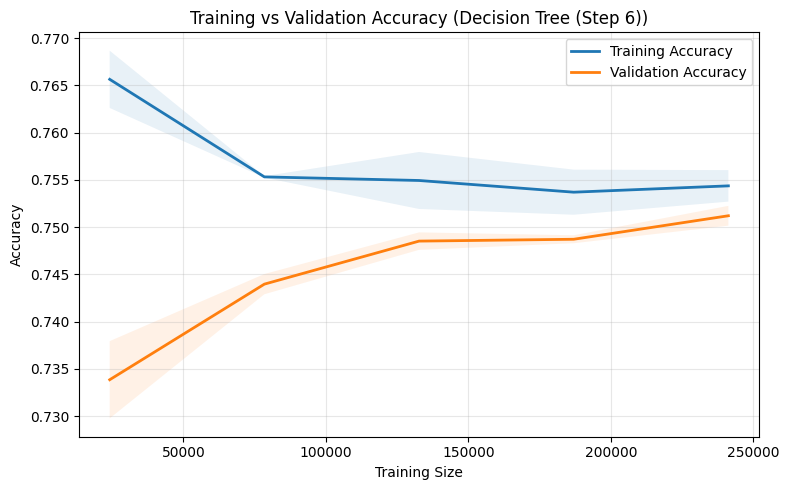


  Accuracy  : 76.20%
              precision    recall  f1-score   support

           S       0.88      0.79      0.83     45241
       non-S       0.53      0.68      0.60     15816

    accuracy                           0.76     61057
   macro avg       0.70      0.74      0.71     61057
weighted avg       0.79      0.76      0.77     61057



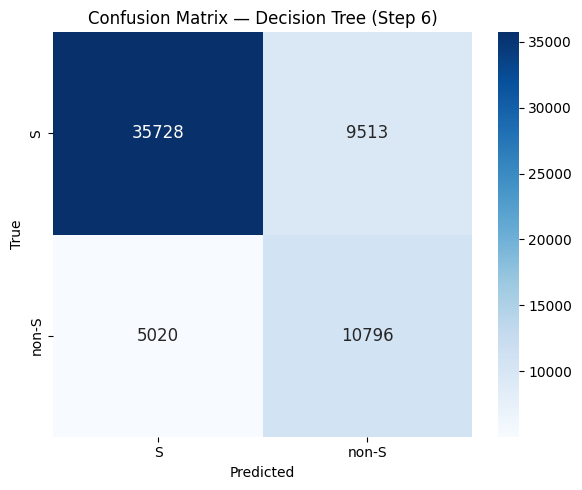


  ──────────────────────────────────────────────────
  Decision Tree (Step 6) — Binary Prediction
  ──────────────────────────────────────────────────
  Rank 1 → Sensitive (S)           58.5%  ███████████
  Rank 2 → Non-sensitive (I+R)     41.5%  ████████
  ──────────────────────────────────────────────────

  Step 6 — Random Forest


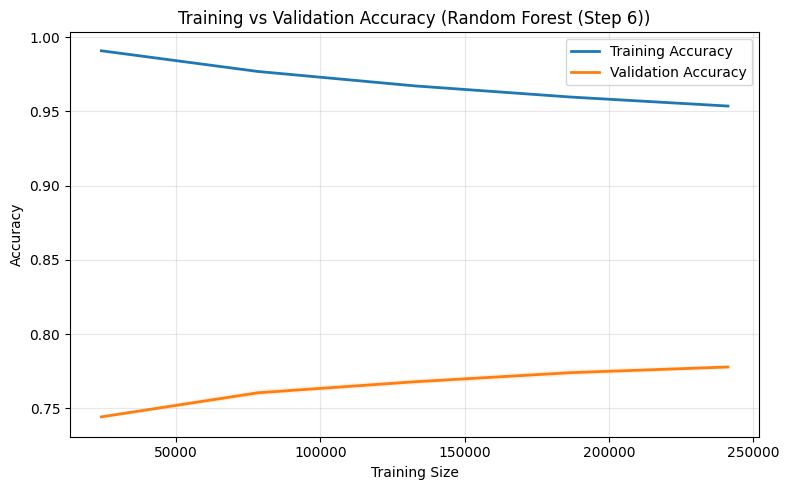


  Accuracy  : 77.14%
              precision    recall  f1-score   support

           S       0.88      0.80      0.84     45241
       non-S       0.55      0.70      0.61     15816

    accuracy                           0.77     61057
   macro avg       0.71      0.75      0.73     61057
weighted avg       0.80      0.77      0.78     61057



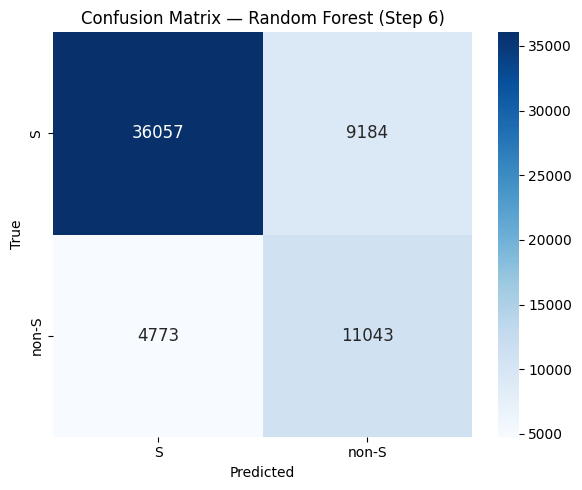


  ──────────────────────────────────────────────────
  Random Forest (Step 6) — Binary Prediction
  ──────────────────────────────────────────────────
  Rank 1 → Sensitive (S)           63.5%  ████████████
  Rank 2 → Non-sensitive (I+R)     36.5%  ███████
  ──────────────────────────────────────────────────

  Step 6 — XGBoost


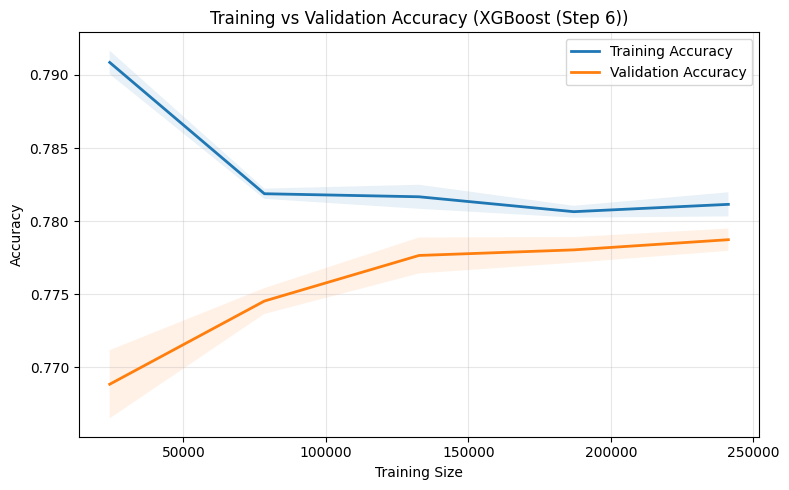


  Accuracy  : 76.79%
              precision    recall  f1-score   support

           S       0.89      0.79      0.83     45241
       non-S       0.54      0.71      0.61     15816

    accuracy                           0.77     61057
   macro avg       0.71      0.75      0.72     61057
weighted avg       0.80      0.77      0.78     61057



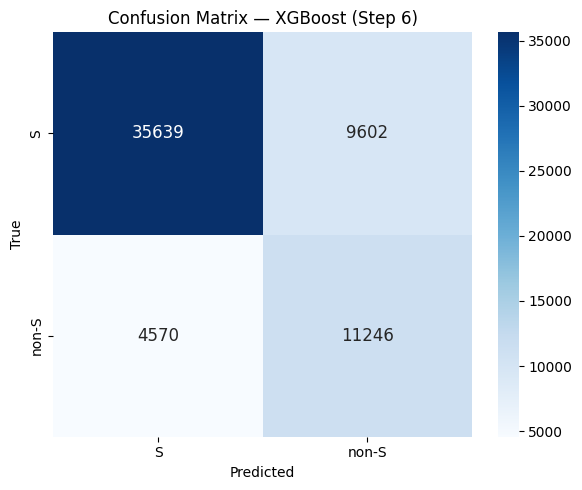


  ──────────────────────────────────────────────────
  XGBoost (Step 6) — Binary Prediction
  ──────────────────────────────────────────────────
  Rank 1 → Sensitive (S)           59.4%  ███████████
  Rank 2 → Non-sensitive (I+R)     40.6%  ████████
  ──────────────────────────────────────────────────

  Step 6 — CatBoost
  Skipping learning curve for CatBoost to avoid sklearn-CatBoost CV issue.

  Accuracy  : 75.38%
              precision    recall  f1-score   support

           S       0.89      0.76      0.82     45241
       non-S       0.52      0.74      0.61     15816

    accuracy                           0.75     61057
   macro avg       0.70      0.75      0.71     61057
weighted avg       0.79      0.75      0.77     61057



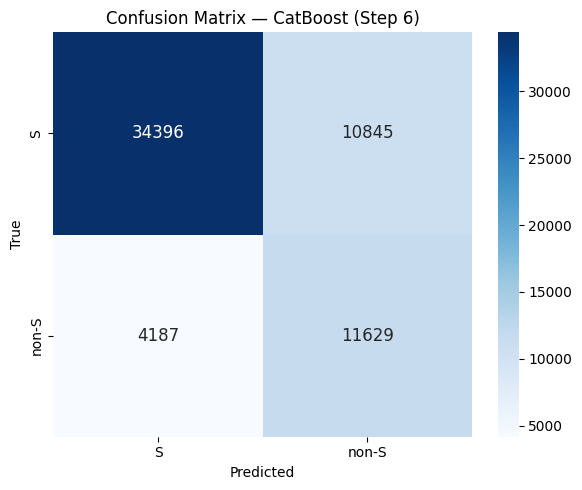


  ──────────────────────────────────────────────────
  CatBoost (Step 6) — Binary Prediction
  ──────────────────────────────────────────────────
  Rank 1 → Sensitive (S)           58.7%  ███████████
  Rank 2 → Non-sensitive (I+R)     41.3%  ████████
  ──────────────────────────────────────────────────


In [45]:
# ============================================================
# STEP 6.4 — Train & Evaluate Models
# ============================================================

summary = {}
predictions = {}

# ------------------------------------------------------------
# Decision Tree
# ------------------------------------------------------------

dt = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt, dt_pred, summary['Decision Tree'] = evaluate_model_display(
    model_name='Decision Tree',
    model=dt,
    X_train=X_train_enc,
    y_train=y_train_enc,
    X_test=X_test_enc,
    y_test=y_test,
    filename_prefix='dt',
    is_catboost=False
)

predictions['Decision Tree'] = dt_pred


# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf, rf_pred, summary['Random Forest'] = evaluate_model_display(
    model_name='Random Forest',
    model=rf,
    X_train=X_train_enc,
    y_train=y_train_enc,
    X_test=X_test_enc,
    y_test=y_test,
    filename_prefix='rf',
    is_catboost=False
)

predictions['Random Forest'] = rf_pred


# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb, xgb_pred, summary['XGBoost'] = evaluate_model_display(
    model_name='XGBoost',
    model=xgb,
    X_train=X_train_enc,
    y_train=y_train_enc,
    X_test=X_test_enc,
    y_test=y_test,
    filename_prefix='xgb',
    is_catboost=False
)

predictions['XGBoost'] = xgb_pred


# ------------------------------------------------------------
# CatBoost
# ------------------------------------------------------------

cat_features_str = [
    'org_clean_final',
    'anti_name_clean',
    'specimen_clean',
    'sex',
    'ward_admit_code'
]

cat_model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    cat_features=cat_features_str,
    verbose=0
)

cat_model, cat_pred, summary['CatBoost'] = evaluate_model_display(
    model_name='CatBoost',
    model=cat_model,
    X_train=X_train_cat,
    y_train=y_train,
    X_test=X_test_cat,
    y_test=y_test,
    filename_prefix='catboost',
    is_catboost=True
)

predictions['CatBoost'] = cat_pred


##STEP 6.5 — Model Comparison Table

In [46]:

# ============================================================
# STEP 6.5 — Model Comparison Table
# ============================================================

df_model_comparison_step6 = (
    pd.DataFrame(summary)
    .T
    .reset_index()
)

df_model_comparison_step6 = (
    df_model_comparison_step6
    .rename(columns={'index': 'Model'})
)

df_model_comparison_step6 = (
    df_model_comparison_step6
    .sort_values(
        'Test Accuracy',
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "="*60)
print("  STEP 6.5 — Model Comparison")
print("="*60)

display(df_model_comparison_step6)

best_name = df_model_comparison_step6.loc[0, 'Model']
best_acc  = df_model_comparison_step6.loc[0, 'Test Accuracy']
best_f1   = df_model_comparison_step6.loc[0, 'F1-score']

print(f"\n  Best Model : {best_name}")
print(f"  Accuracy   : {best_acc*100:.2f}%")
print(f"  Macro F1   : {best_f1:.4f}")






  STEP 6.5 — Model Comparison


,Model,Test Accuracy,Precision,Recall,F1-score
0,Random Forest,0.771410,0.714527,0.747608,0.725306
1,XGBoost,0.767889,0.712886,0.749405,0.723806
2,Decision Tree,0.761977,0.704195,0.736163,0.714346
3,CatBoost,0.753804,0.704462,0.747776,0.714044



  Best Model : Random Forest
  Accuracy   : 77.14%
  Macro F1   : 0.7253


## STEP 6.6 — Plot Model Comparison

### STEP 6.6.1 — Learning Curve Helper

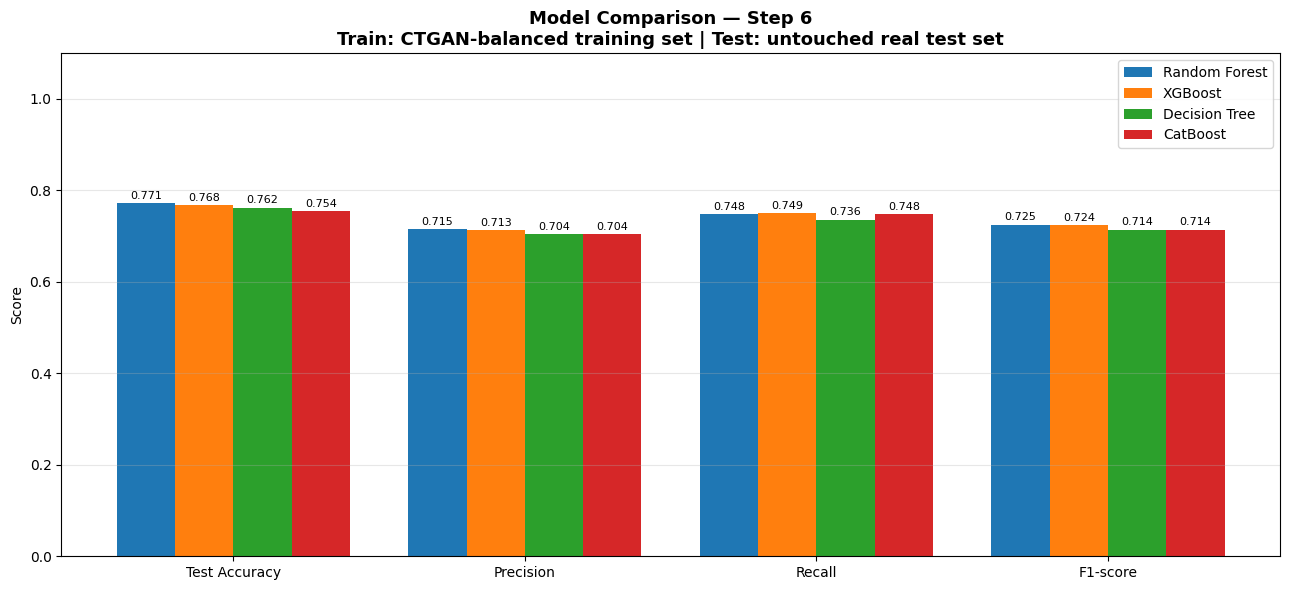

In [47]:
# ─────────────────────────────────────────────
# STEP 6.6.1 — Learning Curve Helper
# ─────────────────────────────────────────────

metrics = [
    'Test Accuracy',
    'Precision',
    'Recall',
    'F1-score'
]

x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 6))

for i, row in df_model_comparison_step6.iterrows():

    vals = [row[m] for m in metrics]

    bars = ax.bar(
        x + i*width,
        vals,
        width,
        label=row['Model']
    )

    for bar, val in zip(bars, vals):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)

ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)

ax.set_title(
    'Model Comparison — Step 6\n'
    'Train: CTGAN-balanced training set | '
    'Test: untouched real test set',
    fontsize=13,
    fontweight='bold'
)

ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(
    'model_comparison_step6_real_test.png',
    dpi=120,
    bbox_inches='tight'
)

plt.show()

###STEP 6.6.2 — Plot Model Comparison

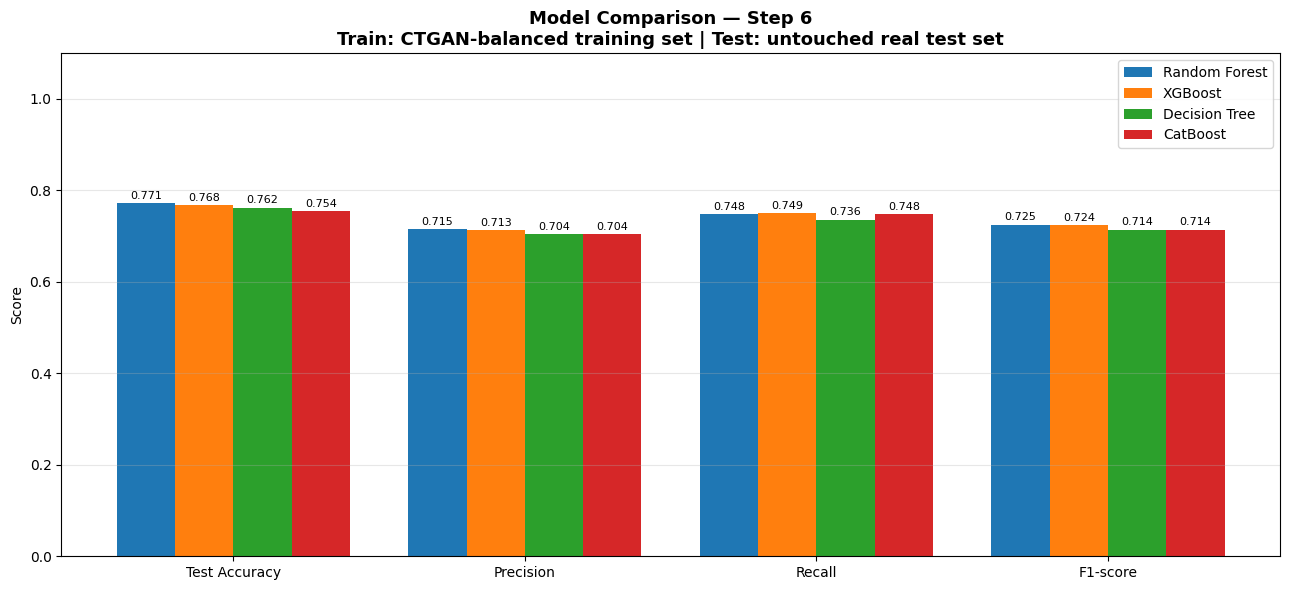

In [48]:
# ============================================================
# STEP 6.6.2 — Plot Model Comparison
# ============================================================

metrics = ['Test Accuracy', 'Precision', 'Recall', 'F1-score']
x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 6))

for i, row in df_model_comparison_step6.iterrows():
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=row['Model'])
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title(
    'Model Comparison — Step 6\n'
    'Train: CTGAN-balanced training set | Test: untouched real test set',
    fontsize=13,
    fontweight='bold'
)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_step6_real_test.png', dpi=120, bbox_inches='tight')
plt.show()


   — Learning Curve CatBoost


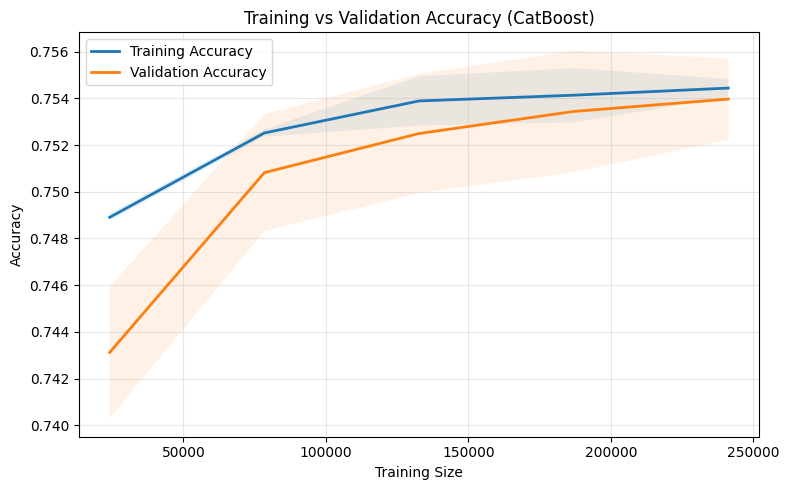

  ✅ Learning Curve CatBoost (Step 6) Done


In [49]:
# ─────────────────────────────────────────────
#  — Learning Curve CatBoost (Step 6)
# ─────────────────────────────────────────────
print("\n" + "="*60)
print("   — Learning Curve CatBoost")
print("="*60)

# ใช้ X_enc_train แทน X_cat_train
# เพราะ learning_curve ต้องการ sklearn-compatible estimator
# CatBoost รับ numeric ได้เช่นกัน
from catboost import CatBoostClassifier
import numpy as np

cat_lc = CatBoostClassifier(
    iterations=100, learning_rate=0.1, depth=6,
    random_seed=42,
    verbose=0)

sizes_cat, tr_sc_cat, val_sc_cat = learning_curve(
    cat_lc,
    X_train_enc,
    y_train_enc,
    cv=3,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

plot_learning_curve(
    sizes_cat, tr_sc_cat, val_sc_cat,
    'CatBoost', 'lc_catboost.png')

print("  ✅ Learning Curve CatBoost (Step 6) Done")

## STEP 6.7 — CTGAN Table for Paper

In [50]:
# ============================================================
# STEP 6.7 — CTGAN Table for Paper
# ============================================================

before_counts = (
    train_real['binary_result']
    .value_counts()
)

after_counts = (
    train_balanced['binary_result']
    .value_counts()
)

table4_ctgan_step6 = pd.DataFrame({
    'Class': ['S', 'non-S', 'Total'],

    'Before CTGAN in Training Set (n)': [
        before_counts.get('S', 0),
        before_counts.get('non-S', 0),
        before_counts.sum()
    ],

    'Before CTGAN (%)': [
        before_counts.get('S', 0)
        / before_counts.sum() * 100,

        before_counts.get('non-S', 0)
        / before_counts.sum() * 100,

        100
    ],

    'After CTGAN in Training Set (n)': [
        after_counts.get('S', 0),
        after_counts.get('non-S', 0),
        after_counts.sum()
    ],

    'After CTGAN (%)': [
        after_counts.get('S', 0)
        / after_counts.sum() * 100,

        after_counts.get('non-S', 0)
        / after_counts.sum() * 100,

        100
    ]
})

print("\n" + "="*60)
print("  STEP 6.7 — CTGAN Balance Table")
print("="*60)

display(table4_ctgan_step6)




  STEP 6.7 — CTGAN Balance Table


,Class,Before CTGAN in Training Set (n),Before CTGAN (%),After CTGAN in Training Set (n),After CTGAN (%)
0,S,180962,74.096427,180962,50.0
1,non-S,63263,25.903573,180962,50.0
2,Total,244225,100.000000,361924,100.0


## STEP 6.8 — Save Result Tables

In [51]:
# ============================================================
# STEP 6.8 — Save Result Tables
# ============================================================

df_model_comparison_step6.to_csv(
    'table1_model_comparison_step6_real_test.csv',
    index=False
)

table4_ctgan_step6.to_csv(
    'table4_ctgan_training_only_step6.csv',
    index=False
)

pd.DataFrame({
    'y_true': y_test,
    'RandomForest_pred': predictions['Random Forest']
}).to_csv(
    'rf_predictions_step6_real_test.csv',
    index=False
)

print("\n✅ Saved output files:")
print("table1_model_comparison_step6_real_test.csv")
print("table4_ctgan_training_only_step6.csv")
print("rf_predictions_step6_real_test.csv")


✅ Saved output files:
table1_model_comparison_step6_real_test.csv
table4_ctgan_training_only_step6.csv
rf_predictions_step6_real_test.csv


#STEP 7 : anti + specimen + sex + age + ward (CTGAN Balanced)

In [52]:
# ============================================================
# STEP 7 — Binary Classification
# Remove Organism Feature
# ============================================================

print("\n" + "="*60)
print("  STEP 7 — Remove Organism Feature")
print("="*60)



  STEP 7 — Remove Organism Feature


## STEP 7.1 — Feature Subset

In [53]:
# ------------------------------------------------------------
# STEP 7.1 — Feature Subset
# ------------------------------------------------------------

step7_features = [
    'anti_name_clean',
    'specimen_clean',
    'sex',
    'age',
    'ward_admit_code'
]

print("\nSTEP 7 Features:")
print(step7_features)


STEP 7 Features:
['anti_name_clean', 'specimen_clean', 'sex', 'age', 'ward_admit_code']


## STEP 7.2 — Encode Train/Test

In [54]:
# ------------------------------------------------------------
# STEP 7.2 — Encode Train/Test
# ------------------------------------------------------------

X7_train_enc, X7_test_enc, encoders_step7 = encode_train_test(
    train_balanced,
    test_real,
    step7_features
)

y7_train_enc = y_to_int(train_balanced['binary_result'])
y7_test_enc  = y_to_int(test_real['binary_result'])

X7_train_cat = train_balanced[step7_features].copy()
X7_test_cat  = test_real[step7_features].copy()

for col in [
    'anti_name_clean',
    'specimen_clean',
    'sex',
    'ward_admit_code'
]:
    X7_train_cat[col] = X7_train_cat[col].astype(str)
    X7_test_cat[col]  = X7_test_cat[col].astype(str)

y7_train = train_balanced['binary_result'].copy()
y7_test  = test_real['binary_result'].copy()

print(f"\nX7_train_enc : {X7_train_enc.shape}")
print(f"X7_test_enc  : {X7_test_enc.shape}")



X7_train_enc : (361924, 5)
X7_test_enc  : (61057, 5)


##STEP 7.3 — Train & Evaluate Models


  Step 7 — Decision Tree


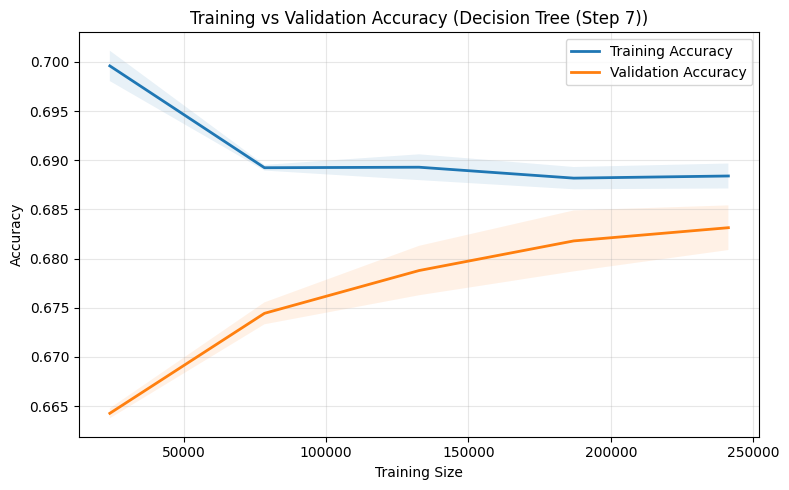


  Accuracy  : 68.56%
              precision    recall  f1-score   support

           S       0.83      0.72      0.77     45241
       non-S       0.42      0.58      0.49     15816

    accuracy                           0.69     61057
   macro avg       0.63      0.65      0.63     61057
weighted avg       0.72      0.69      0.70     61057



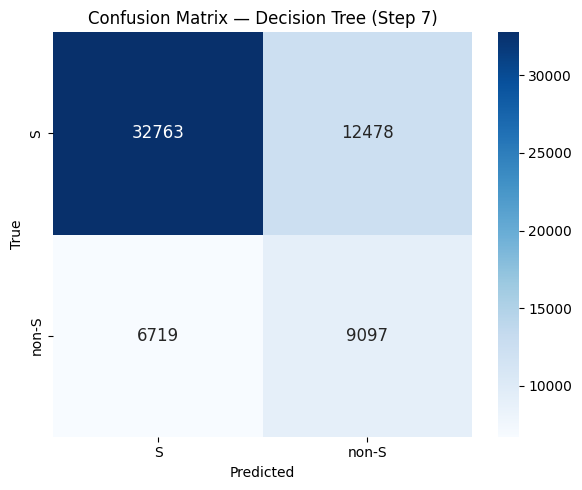


  ──────────────────────────────────────────────────
  Decision Tree (Step 7) — Binary Prediction
  ──────────────────────────────────────────────────
  Rank 1 → Sensitive (S)           56.1%  ███████████
  Rank 2 → Non-sensitive (I+R)     43.9%  ████████
  ──────────────────────────────────────────────────

  Step 7 — Random Forest


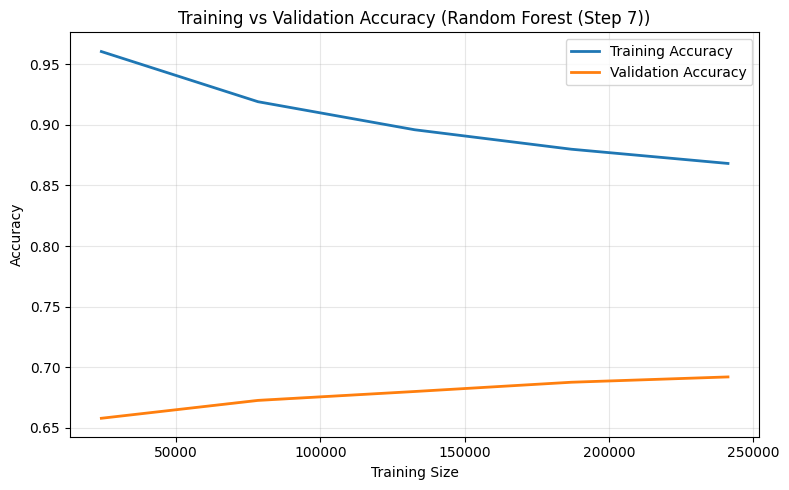


  Accuracy  : 66.81%
              precision    recall  f1-score   support

           S       0.82      0.71      0.76     45241
       non-S       0.40      0.56      0.46     15816

    accuracy                           0.67     61057
   macro avg       0.61      0.63      0.61     61057
weighted avg       0.71      0.67      0.68     61057



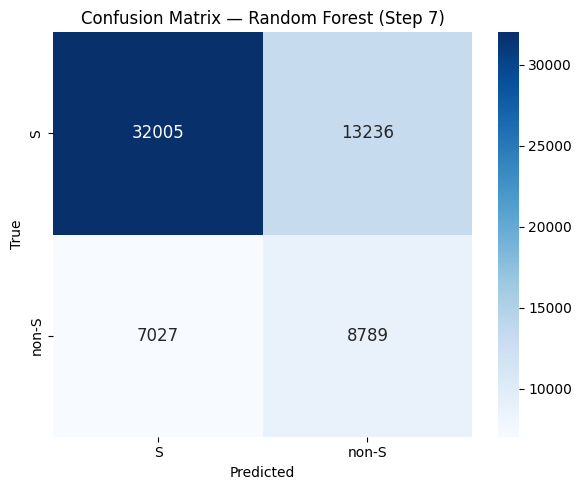


  ──────────────────────────────────────────────────
  Random Forest (Step 7) — Binary Prediction
  ──────────────────────────────────────────────────
  Rank 1 → Sensitive (S)           60.9%  ████████████
  Rank 2 → Non-sensitive (I+R)     39.1%  ███████
  ──────────────────────────────────────────────────

  Step 7 — XGBoost


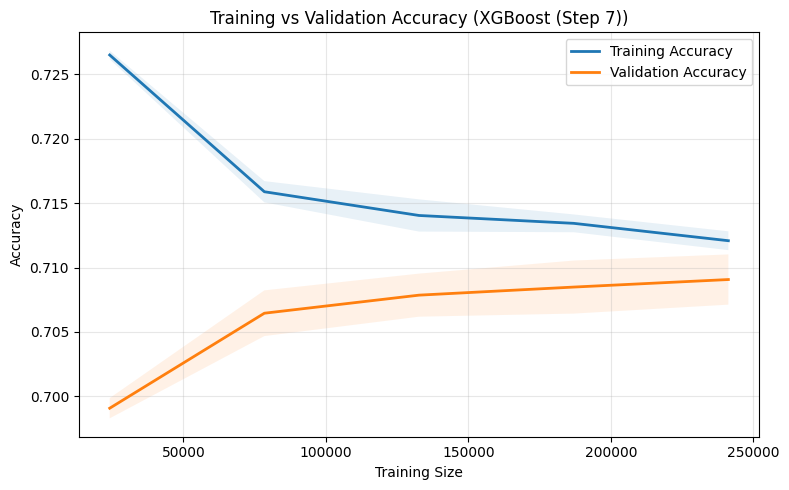


  Accuracy  : 68.72%
              precision    recall  f1-score   support

           S       0.84      0.72      0.77     45241
       non-S       0.43      0.60      0.50     15816

    accuracy                           0.69     61057
   macro avg       0.63      0.66      0.64     61057
weighted avg       0.73      0.69      0.70     61057



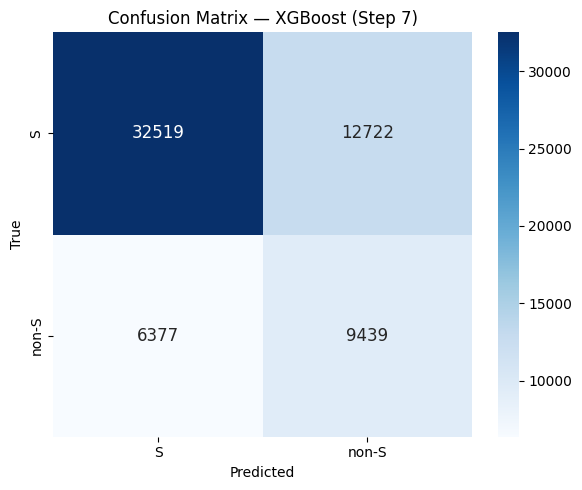


  ──────────────────────────────────────────────────
  XGBoost (Step 7) — Binary Prediction
  ──────────────────────────────────────────────────
  Rank 1 → Sensitive (S)           57.0%  ███████████
  Rank 2 → Non-sensitive (I+R)     43.0%  ████████
  ──────────────────────────────────────────────────

  Step 7 — CatBoost
  Skipping learning curve for CatBoost to avoid sklearn-CatBoost CV issue.

  Accuracy  : 67.39%
              precision    recall  f1-score   support

           S       0.84      0.70      0.76     45241
       non-S       0.41      0.61      0.49     15816

    accuracy                           0.67     61057
   macro avg       0.62      0.65      0.63     61057
weighted avg       0.73      0.67      0.69     61057



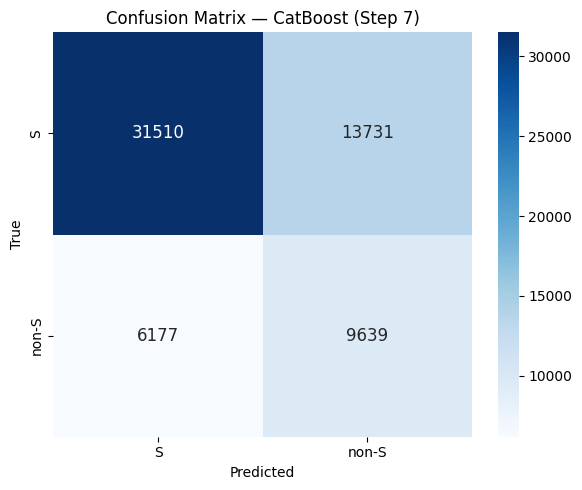


  ──────────────────────────────────────────────────
  CatBoost (Step 7) — Binary Prediction
  ──────────────────────────────────────────────────
  Rank 1 → Sensitive (S)           56.0%  ███████████
  Rank 2 → Non-sensitive (I+R)     44.0%  ████████
  ──────────────────────────────────────────────────


In [55]:
# ------------------------------------------------------------
# STEP 7.3 — Train & Evaluate Models
# ------------------------------------------------------------

summary7 = {}
predictions7 = {}

# Decision Tree
dt7 = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt7, dt7_pred, summary7['Decision Tree'] = evaluate_model_display(
    model_name='Decision Tree',
    model=dt7,
    X_train=X7_train_enc,
    y_train=y7_train_enc,
    X_test=X7_test_enc,
    y_test=y7_test,
    filename_prefix='step7_dt',
    step_label='Step 7',
    is_catboost=False
)

predictions7['Decision Tree'] = dt7_pred


# Random Forest
rf7 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf7, rf7_pred, summary7['Random Forest'] = evaluate_model_display(
    model_name='Random Forest',
    model=rf7,
    X_train=X7_train_enc,
    y_train=y7_train_enc,
    X_test=X7_test_enc,
    y_test=y7_test,
    filename_prefix='step7_rf',
    step_label='Step 7',
    is_catboost=False
)

predictions7['Random Forest'] = rf7_pred


# XGBoost
xgb7 = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb7, xgb7_pred, summary7['XGBoost'] = evaluate_model_display(
    model_name='XGBoost',
    model=xgb7,
    X_train=X7_train_enc,
    y_train=y7_train_enc,
    X_test=X7_test_enc,
    y_test=y7_test,
    filename_prefix='step7_xgb',
    step_label='Step 7',
    is_catboost=False
)

predictions7['XGBoost'] = xgb7_pred


# CatBoost
cat_features_step7 = [
    'anti_name_clean',
    'specimen_clean',
    'sex',
    'ward_admit_code'
]

cat7 = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    cat_features=cat_features_step7,
    verbose=0
)

cat7, cat7_pred, summary7['CatBoost'] = evaluate_model_display(
    model_name='CatBoost',
    model=cat7,
    X_train=X7_train_cat,
    y_train=y7_train,
    X_test=X7_test_cat,
    y_test=y7_test,
    filename_prefix='step7_catboost',
    step_label='Step 7',
    is_catboost=True
)

predictions7['CatBoost'] = cat7_pred


##STEP 7.4 — Comparison Table

In [56]:
# ------------------------------------------------------------
# STEP 7.4 — Comparison Table
# ------------------------------------------------------------

df_model_comparison_step7 = (
    pd.DataFrame(summary7)
    .T
    .reset_index()
)

df_model_comparison_step7 = (
    df_model_comparison_step7
    .rename(columns={'index': 'Model'})
)

df_model_comparison_step7 = (
    df_model_comparison_step7
    .sort_values(
        'Test Accuracy',
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "="*60)
print("  STEP 7 — Model Comparison")
print("="*60)

display(df_model_comparison_step7)


  STEP 7 — Model Comparison


,Model,Test Accuracy,Precision,Recall,F1-score
0,XGBoost,0.687194,0.630989,0.657798,0.635046
1,Decision Tree,0.685589,0.625733,0.649683,0.630001
2,CatBoost,0.673944,0.624275,0.652969,0.625949
3,Random Forest,0.668130,0.609507,0.631568,0.612039


# STEP 8 — ML : anti +Specimen + Sex + Age (CTGAN Balanced)

###  STEP 8.1 — เตรียม Dataset จาก df_ipd_augmented

In [57]:
# ============================================================
# STEP 8 — Binary Classification
# Remove Organism + Ward
# ============================================================

print("\n" + "="*60)
print("  STEP 8 — Remove Organism + Ward")
print("="*60)


  STEP 8 — Remove Organism + Ward


##STEP 8.1 — Feature Subset

In [58]:
# ------------------------------------------------------------
# STEP 8.1 — Feature Subset
# ------------------------------------------------------------

step8_features = [
    'anti_name_clean',
    'specimen_clean',
    'sex',
    'age'
]

print("\nSTEP 8 Features:")
print(step8_features)


STEP 8 Features:
['anti_name_clean', 'specimen_clean', 'sex', 'age']


##STEP 8.2 — Encode Train/Test

In [59]:
# ------------------------------------------------------------
# STEP 8.2 — Encode Train/Test
# ------------------------------------------------------------

X8_train_enc, X8_test_enc, encoders_step8 = encode_train_test(
    train_balanced,
    test_real,
    step8_features
)

y8_train_enc = y_to_int(train_balanced['binary_result'])
y8_test_enc  = y_to_int(test_real['binary_result'])

X8_train_cat = train_balanced[step8_features].copy()
X8_test_cat  = test_real[step8_features].copy()

for col in [
    'anti_name_clean',
    'specimen_clean',
    'sex'
]:
    X8_train_cat[col] = X8_train_cat[col].astype(str)
    X8_test_cat[col]  = X8_test_cat[col].astype(str)

y8_train = train_balanced['binary_result'].copy()
y8_test  = test_real['binary_result'].copy()

print(f"\nX8_train_enc : {X8_train_enc.shape}")
print(f"X8_test_enc  : {X8_test_enc.shape}")


X8_train_enc : (361924, 4)
X8_test_enc  : (61057, 4)


##STEP 8.3 — Train & Evaluate Models


  Step 8 — Decision Tree


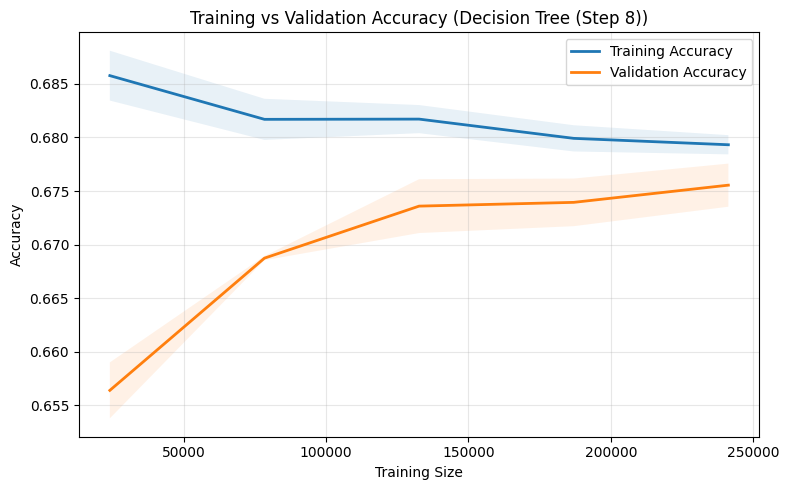


  Accuracy  : 68.32%
              precision    recall  f1-score   support

           S       0.83      0.72      0.77     45241
       non-S       0.42      0.57      0.48     15816

    accuracy                           0.68     61057
   macro avg       0.62      0.65      0.63     61057
weighted avg       0.72      0.68      0.70     61057



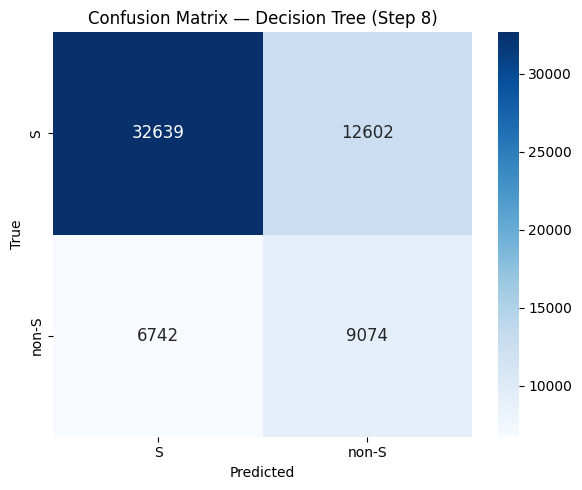


  ──────────────────────────────────────────────────
  Decision Tree (Step 8) — Binary Prediction
  ──────────────────────────────────────────────────
  Rank 1 → Sensitive (S)           55.5%  ███████████
  Rank 2 → Non-sensitive (I+R)     44.5%  ████████
  ──────────────────────────────────────────────────

  Step 8 — Random Forest


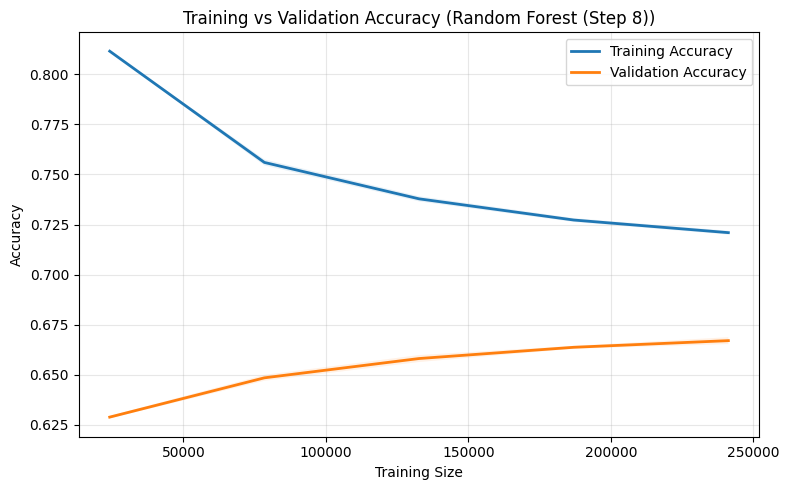


  Accuracy  : 65.61%
              precision    recall  f1-score   support

           S       0.83      0.67      0.74     45241
       non-S       0.39      0.60      0.48     15816

    accuracy                           0.66     61057
   macro avg       0.61      0.64      0.61     61057
weighted avg       0.72      0.66      0.67     61057



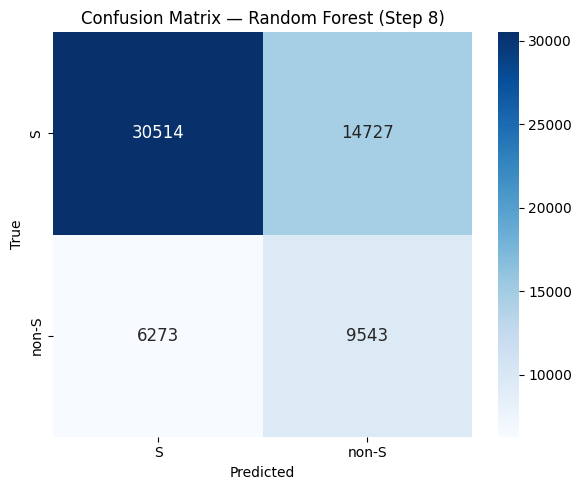


  ──────────────────────────────────────────────────
  Random Forest (Step 8) — Binary Prediction
  ──────────────────────────────────────────────────
  Rank 1 → Sensitive (S)           56.3%  ███████████
  Rank 2 → Non-sensitive (I+R)     43.7%  ████████
  ──────────────────────────────────────────────────

  Step 8 — XGBoost


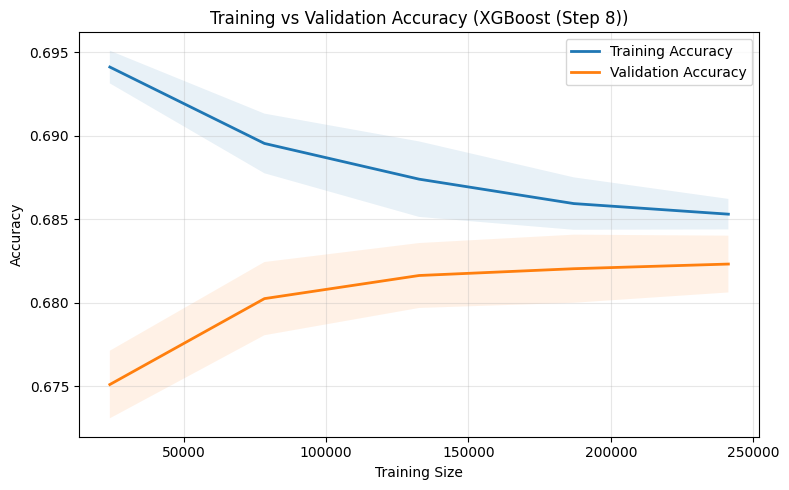


  Accuracy  : 66.83%
              precision    recall  f1-score   support

           S       0.84      0.69      0.75     45241
       non-S       0.41      0.62      0.49     15816

    accuracy                           0.67     61057
   macro avg       0.62      0.65      0.62     61057
weighted avg       0.73      0.67      0.69     61057



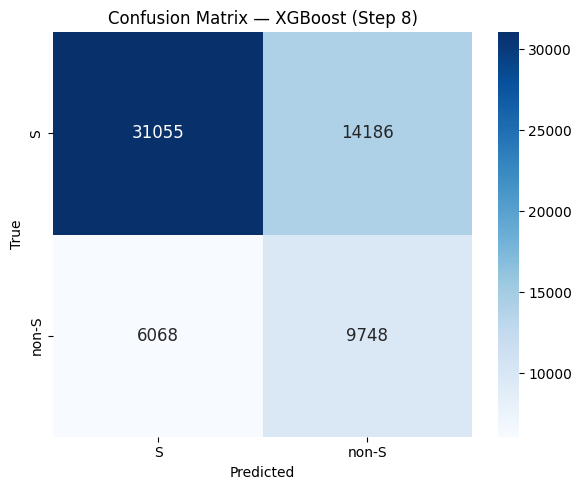


  ──────────────────────────────────────────────────
  XGBoost (Step 8) — Binary Prediction
  ──────────────────────────────────────────────────
  Rank 1 → Sensitive (S)           55.3%  ███████████
  Rank 2 → Non-sensitive (I+R)     44.7%  ████████
  ──────────────────────────────────────────────────

  Step 8 — CatBoost
  Skipping learning curve for CatBoost to avoid sklearn-CatBoost CV issue.

  Accuracy  : 67.31%
              precision    recall  f1-score   support

           S       0.83      0.70      0.76     45241
       non-S       0.41      0.60      0.49     15816

    accuracy                           0.67     61057
   macro avg       0.62      0.65      0.62     61057
weighted avg       0.72      0.67      0.69     61057



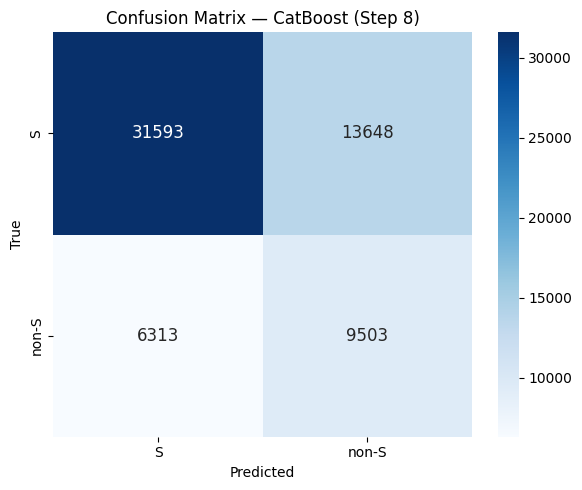


  ──────────────────────────────────────────────────
  CatBoost (Step 8) — Binary Prediction
  ──────────────────────────────────────────────────
  Rank 1 → Sensitive (S)           55.2%  ███████████
  Rank 2 → Non-sensitive (I+R)     44.8%  ████████
  ──────────────────────────────────────────────────


In [60]:
# ------------------------------------------------------------
# STEP 8.3 — Train & Evaluate Models
# ------------------------------------------------------------

summary8 = {}
predictions8 = {}

# Decision Tree
dt8 = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt8, dt8_pred, summary8['Decision Tree'] = evaluate_model_display(
    model_name='Decision Tree',
    model=dt8,
    X_train=X8_train_enc,
    y_train=y8_train_enc,
    X_test=X8_test_enc,
    y_test=y8_test,
    filename_prefix='step8_dt',
    step_label='Step 8',
    is_catboost=False
)

predictions8['Decision Tree'] = dt8_pred


# Random Forest
rf8 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf8, rf8_pred, summary8['Random Forest'] = evaluate_model_display(
    model_name='Random Forest',
    model=rf8,
    X_train=X8_train_enc,
    y_train=y8_train_enc,
    X_test=X8_test_enc,
    y_test=y8_test,
    filename_prefix='step8_rf',
    step_label='Step 8',
    is_catboost=False
)

predictions8['Random Forest'] = rf8_pred


# XGBoost
xgb8 = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb8, xgb8_pred, summary8['XGBoost'] = evaluate_model_display(
    model_name='XGBoost',
    model=xgb8,
    X_train=X8_train_enc,
    y_train=y8_train_enc,
    X_test=X8_test_enc,
    y_test=y8_test,
    filename_prefix='step8_xgb',
    step_label='Step 8',
    is_catboost=False
)

predictions8['XGBoost'] = xgb8_pred


# CatBoost
cat_features_step8 = [
    'anti_name_clean',
    'specimen_clean',
    'sex'
]

cat8 = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    cat_features=cat_features_step8,
    verbose=0
)

cat8, cat8_pred, summary8['CatBoost'] = evaluate_model_display(
    model_name='CatBoost',
    model=cat8,
    X_train=X8_train_cat,
    y_train=y8_train,
    X_test=X8_test_cat,
    y_test=y8_test,
    filename_prefix='step8_catboost',
    step_label='Step 8',
    is_catboost=True
)

predictions8['CatBoost'] = cat8_pred

##STEP 8.4 — Comparison Table

In [61]:
# ------------------------------------------------------------
# STEP 8.4 — Comparison Table
# ------------------------------------------------------------

df_model_comparison_step8 = (
    pd.DataFrame(summary8)
    .T
    .reset_index()
)

df_model_comparison_step8 = (
    df_model_comparison_step8
    .rename(columns={'index': 'Model'})
)

df_model_comparison_step8 = (
    df_model_comparison_step8
    .sort_values(
        'Test Accuracy',
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "="*60)
print("  STEP 8 — Model Comparison")
print("="*60)

display(df_model_comparison_step8)


  STEP 8 — Model Comparison


,Model,Test Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.683181,0.623710,0.647585,0.627728
1,CatBoost,0.673076,0.621968,0.649587,0.623839
2,XGBoost,0.668277,0.621915,0.651386,0.622279
3,Random Forest,0.656059,0.611340,0.638927,0.610058
